# 04 - Anomaly Detection

## Objective

This notebook investigates statistical methods for identifying anomalously low solar availability from the historical Clear-Sky Index (CSI) series prepared in Notebook 03a.

The purpose of anomaly detection is to identify observations whose normalized solar availability is unusually low relative to an appropriate reference distribution.

An anomaly is not automatically classified as a solar drought.

A solar drought requires persistent anomalously low solar availability and will be investigated separately in Notebook 05.

## Research Question

How should unusually low solar availability be statistically defined from the historical CSI series while accounting for temporal, seasonal, and diurnal variation?

## Anomaly Concept

For an observation at time $t$, the Clear-Sky Index is:

$$
CSI_t =
\frac{GHI_{\text{observed},t}}
{GHI_{\text{clear},t}}
$$

An anomalously low observation is one whose CSI is unusually small relative to an appropriate reference population.

The reference population is critical because CSI may vary systematically with:

- season;
- month;
- hour of day;
- solar geometry;
- atmospheric conditions.

Therefore, a single global threshold should not automatically be assumed to provide an equivalent measure of anomaly across all times of the year.

## Development-Period Constraint

The primary historical dataset currently contains one complete calendar year (2020).

Therefore, the analyses in this notebook are treated as methodological development and sensitivity analysis rather than as final climatological estimates.

A robust climatological anomaly threshold will require a longer historical record.

## Candidate Approaches

The following candidate reference approaches will be investigated:

1. Global empirical percentile thresholds.
2. Month-conditioned empirical percentile thresholds.
3. Month-and-hour-conditioned empirical percentile thresholds where sample sizes permit.
4. Solar-geometry-conditioned approaches.
5. Other reference formulations if justified by the observed distribution.

The candidate methods will be compared rather than selecting a threshold arbitrarily.

## Scientific Principle

No observation will be classified as anomalous solely because it has a low absolute GHI value.

The analysis is based on normalized solar availability.

Nighttime observations are excluded because CSI is undefined when the clear-sky reference is zero.

Low-reliability observations are retained initially and treated using the quality-control information established in Notebook 03a.

No solar-drought threshold is defined in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
data_path = Path(
    "../data/raw/solar/cams_davos_2020_hourly.csv"
)

df = pd.read_csv(
    data_path,
    sep=";",
    comment="#",
    header=None,
    names=[
        "observation_period",
        "toa",
        "clear_sky_ghi",
        "clear_sky_bhi",
        "clear_sky_dhi",
        "clear_sky_bni",
        "ghi",
        "bhi",
        "dhi",
        "bni",
        "reliability",
    ],
)

periods = df["observation_period"].str.split("/", expand=True)

df["start_time"] = pd.to_datetime(periods[0])
df["end_time"] = pd.to_datetime(periods[1])

df = (
    df
    .sort_values("start_time")
    .reset_index(drop=True)
)

print("Shape:", df.shape)
print("Start:", df["start_time"].min())
print("End:", df["end_time"].max())

Shape: (9528, 13)
Start: 2020-01-01 00:00:00
End: 2021-02-01 00:00:00


In [3]:
analysis_start = pd.Timestamp("2020-01-01 00:00:00")
analysis_end = pd.Timestamp("2021-01-01 00:00:00")

df["analysis_period"] = np.where(
    (df["start_time"] >= analysis_start) &
    (df["start_time"] < analysis_end),
    "primary_2020",
    "extension_2021"
)

df["solar_period"] = np.where(
    df["clear_sky_ghi"] == 0,
    "nighttime",
    "daylight"
)

df["csi"] = np.nan

valid_reference = df["clear_sky_ghi"] > 0

df.loc[valid_reference, "csi"] = (
    df.loc[valid_reference, "ghi"]
    /
    df.loc[valid_reference, "clear_sky_ghi"]
)

In [4]:
analysis_df = df[
    (df["analysis_period"] == "primary_2020") &
    (df["csi"].notna())
].copy()

print("========== ANOMALY ANALYSIS POPULATION ==========")

print("Total 2020 observations:", 
      (df["analysis_period"] == "primary_2020").sum())

print("Valid CSI observations:", len(analysis_df))

print("Nighttime observations excluded:",
      ((df["analysis_period"] == "primary_2020") &
       (df["clear_sky_ghi"] == 0)).sum())

========== ANOMALY ANALYSIS POPULATION ==========
Total 2020 observations: 8784
Valid CSI observations: 4768
Nighttime observations excluded: 4016


In [5]:
print("========== 2020 CSI DISTRIBUTION ==========")

print(
    analysis_df["csi"].describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.20,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

========== 2020 CSI DISTRIBUTION ==========
count    4768.000000
mean        0.688845
std         0.316215
min         0.062676
1%          0.082074
5%          0.129638
10%         0.176348
20%         0.324733
25%         0.400020
50%         0.784422
75%         1.000000
90%         1.000000
95%         1.000000
99%         1.000000
max         1.000000
Name: csi, dtype: float64


In [6]:
print("\nCSI = 1:",
      (analysis_df["csi"] == 1).sum())

print(
    "CSI < 0.2:",
    (analysis_df["csi"] < 0.2).sum()
)

print(
    "CSI < 0.5:",
    (analysis_df["csi"] < 0.5).sum()
)


CSI = 1: 1281
CSI < 0.2: 554
CSI < 0.5: 1441


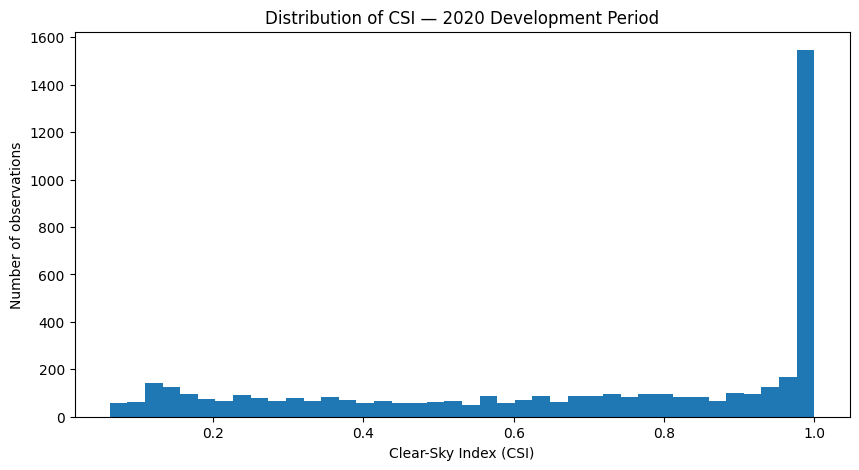

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(
    analysis_df["csi"],
    bins=40
)

plt.xlabel("Clear-Sky Index (CSI)")
plt.ylabel("Number of observations")
plt.title("Distribution of CSI — 2020 Development Period")

plt.show()

In [8]:
global_percentiles = analysis_df["csi"].quantile(
    [0.01, 0.05, 0.10, 0.20, 0.25]
)

print("========== GLOBAL CSI PERCENTILES ==========")
print(global_percentiles)

========== GLOBAL CSI PERCENTILES ==========
0.01    0.082074
0.05    0.129638
0.10    0.176348
0.20    0.324733
0.25    0.400020
Name: csi, dtype: float64


In [9]:
candidate_quantiles = [0.01, 0.05, 0.10, 0.20, 0.25]

global_thresholds = {}

for q in candidate_quantiles:
    threshold = analysis_df["csi"].quantile(q)
    global_thresholds[q] = threshold

print("========== GLOBAL THRESHOLD CANDIDATES ==========")

for q, threshold in global_thresholds.items():
    count = (analysis_df["csi"] < threshold).sum()
    percentage = 100 * count / len(analysis_df)

    print(
        f"{q:.0%} percentile | "
        f"threshold = {threshold:.6f} | "
        f"count = {count} | "
        f"percentage = {percentage:.2f}%"
    )

========== GLOBAL THRESHOLD CANDIDATES ==========
1% percentile | threshold = 0.082074 | count = 48 | percentage = 1.01%
5% percentile | threshold = 0.129638 | count = 239 | percentage = 5.01%
10% percentile | threshold = 0.176348 | count = 477 | percentage = 10.00%
20% percentile | threshold = 0.324733 | count = 954 | percentage = 20.01%
25% percentile | threshold = 0.400020 | count = 1192 | percentage = 25.00%


In [10]:
analysis_df["month"] = analysis_df["start_time"].dt.month

In [11]:
monthly_percentiles = (
    analysis_df
    .groupby("month")["csi"]
    .quantile([0.05, 0.10, 0.20])
    .unstack()
)

monthly_percentiles.columns = [
    "q05",
    "q10",
    "q20"
]

print("========== MONTHLY CSI THRESHOLDS ==========")
print(monthly_percentiles)

========== MONTHLY CSI THRESHOLDS ==========
            q05       q10       q20
month                              
1      0.175853  0.263017  0.505582
2      0.140425  0.166203  0.221040
3      0.155103  0.235646  0.362130
4      0.194833  0.377937  0.629484
5      0.135828  0.179271  0.325451
6      0.116124  0.146312  0.236535
7      0.142923  0.227656  0.396580
8      0.111729  0.152019  0.283435
9      0.106533  0.233039  0.384398
10     0.118916  0.129641  0.233159
11     0.172957  0.409870  0.733581
12     0.122954  0.147123  0.187006


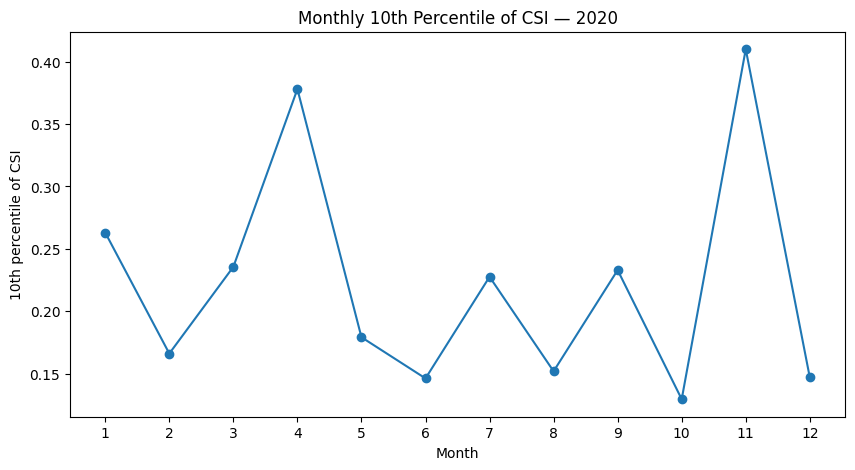

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_percentiles.index,
    monthly_percentiles["q10"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("10th percentile of CSI")
plt.title("Monthly 10th Percentile of CSI — 2020")

plt.xticks(range(1, 13))

plt.show()

In [13]:
monthly_counts = (
    analysis_df
    .groupby("month")
    .size()
)

print("========== MONTHLY SAMPLE SIZES ==========")
print(monthly_counts)

========== MONTHLY SAMPLE SIZES ==========
month
1     296
2     319
3     399
4     435
5     488
6     510
7     509
8     462
9     398
10    365
11    300
12    287
dtype: int64


## Global Threshold: Monthly Anomaly Rates

The global empirical 10th percentile provides a simple baseline anomaly definition.

However, if the underlying CSI distribution varies seasonally, applying a single global threshold may produce different anomaly frequencies across months.

To evaluate this, the global 10th-percentile threshold is applied separately to each month.

If the global threshold represents a comparable level of rarity across the year, the resulting monthly anomaly frequencies should be approximately similar to the nominal 10% level.

Large systematic differences would indicate that seasonal conditioning may be necessary.

In [14]:
global_q10 = analysis_df["csi"].quantile(0.10)

analysis_df["global_anomaly"] = (
    analysis_df["csi"] < global_q10
)

global_monthly_rates = (
    analysis_df
    .groupby("month")["global_anomaly"]
    .agg(
        observations="size",
        anomalies="sum",
        anomaly_rate="mean"
    )
)

global_monthly_rates["anomaly_rate_pct"] = (
    100 * global_monthly_rates["anomaly_rate"]
)

print("========== GLOBAL Q10 MONTHLY ANOMALY RATES ==========")
print(global_monthly_rates)

========== GLOBAL Q10 MONTHLY ANOMALY RATES ==========
       observations  anomalies  anomaly_rate  anomaly_rate_pct
month                                                         
1               296         15      0.050676          5.067568
2               319         45      0.141066         14.106583
3               399         27      0.067669          6.766917
4               435         19      0.043678          4.367816
5               488         48      0.098361          9.836066
6               510         67      0.131373         13.137255
7               509         36      0.070727          7.072692
8               462         56      0.121212         12.121212
9               398         37      0.092965          9.296482
10              365         58      0.158904         15.890411
11              300         16      0.053333          5.333333
12              287         53      0.184669         18.466899


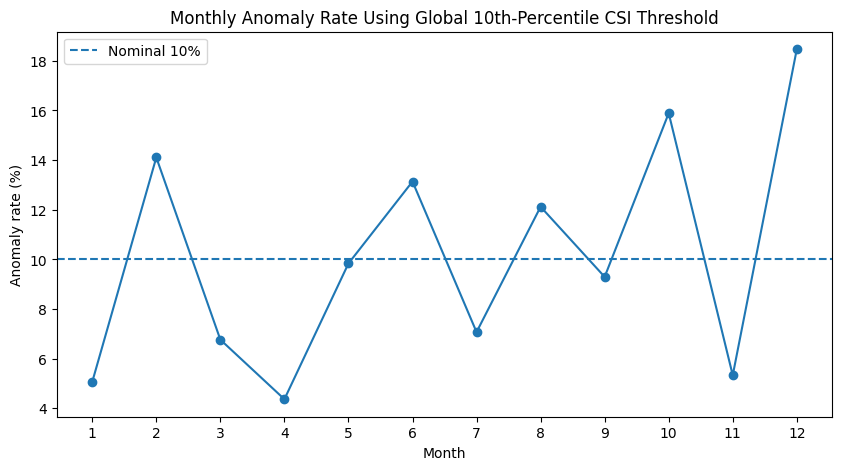

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    global_monthly_rates.index,
    global_monthly_rates["anomaly_rate_pct"],
    marker="o"
)

plt.axhline(
    10,
    linestyle="--",
    label="Nominal 10%"
)

plt.xlabel("Month")
plt.ylabel("Anomaly rate (%)")
plt.title(
    "Monthly Anomaly Rate Using Global 10th-Percentile CSI Threshold"
)

plt.xticks(range(1, 13))
plt.legend()

plt.show()

## Monthly-Conditioned Anomaly Definition

The global-threshold analysis demonstrated that the same CSI threshold produces substantially different anomaly frequencies across months during the 2020 development period.

This indicates that the CSI distribution is seasonally heterogeneous.

As a second candidate approach, an empirical threshold is therefore estimated separately for each month.

For month $m$, the threshold is defined as:

$$
T_m =
Q_{0.10}(CSI \mid month=m)
$$

where $Q_{0.10}$ denotes the empirical 10th percentile.

An observation is classified as a monthly-conditioned anomaly when:

$$
CSI_t < T_m
$$

where $m$ is the calendar month containing observation $t$.

This method is evaluated as a candidate anomaly definition only. It is not yet adopted as the final climatological method because the current development dataset contains only one complete year.

In [16]:
monthly_q10 = (
    analysis_df
    .groupby("month")["csi"]
    .transform("quantile", 0.10)
)

analysis_df["monthly_q10_threshold"] = monthly_q10

analysis_df["monthly_anomaly"] = (
    analysis_df["csi"] <
    analysis_df["monthly_q10_threshold"]
)

print("========== MONTHLY-CONDITIONED ANOMALY RATES ==========")

monthly_anomaly_rates = (
    analysis_df
    .groupby("month")["monthly_anomaly"]
    .agg(
        observations="size",
        anomalies="sum",
        anomaly_rate="mean"
    )
)

monthly_anomaly_rates["anomaly_rate_pct"] = (
    100 * monthly_anomaly_rates["anomaly_rate"]
)

print(monthly_anomaly_rates)

========== MONTHLY-CONDITIONED ANOMALY RATES ==========
       observations  anomalies  anomaly_rate  anomaly_rate_pct
month                                                         
1               296         30      0.101351         10.135135
2               319         32      0.100313         10.031348
3               399         40      0.100251         10.025063
4               435         44      0.101149         10.114943
5               488         49      0.100410         10.040984
6               510         51      0.100000         10.000000
7               509         51      0.100196         10.019646
8               462         47      0.101732         10.173160
9               398         40      0.100503         10.050251
10              365         37      0.101370         10.136986
11              300         30      0.100000         10.000000
12              287         29      0.101045         10.104530


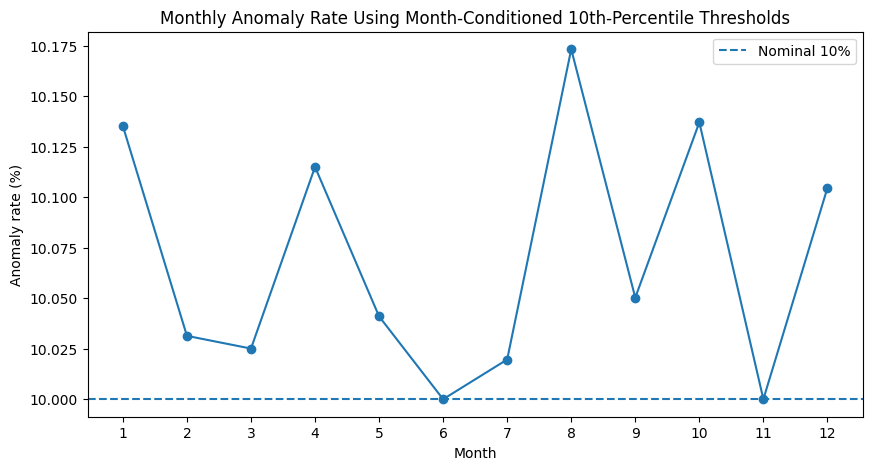

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_anomaly_rates.index,
    monthly_anomaly_rates["anomaly_rate_pct"],
    marker="o"
)

plt.axhline(
    10,
    linestyle="--",
    label="Nominal 10%"
)

plt.xlabel("Month")
plt.ylabel("Anomaly rate (%)")
plt.title(
    "Monthly Anomaly Rate Using Month-Conditioned 10th-Percentile Thresholds"
)

plt.xticks(range(1, 13))
plt.legend()

plt.show()

## Month-and-Hour Conditional Sample Sizes

The monthly analysis demonstrates substantial seasonal variation in the CSI distribution.

However, solar availability also varies systematically throughout the day.

A possible extension is therefore to condition the CSI reference distribution jointly on month and hour:

$$
T_{m,h}
=
Q_{0.10}(CSI\mid month=m,\ hour=h)
$$

Before constructing such thresholds, the available sample size for each month-hour combination must be examined.

This is important because the current development dataset contains only one calendar year. Consequently, each month-hour combination contains only a limited number of observations.

Month-hour conditional thresholds will therefore be treated as a diagnostic candidate rather than automatically adopted.

In [18]:
analysis_df["hour"] = analysis_df["start_time"].dt.hour

month_hour_counts = (
    analysis_df
    .groupby(["month", "hour"])
    .size()
)

print("========== MONTH × HOUR SAMPLE SIZES ==========")

print(month_hour_counts)

========== MONTH × HOUR SAMPLE SIZES ==========
month  hour
1      6        6
       7       31
       8       31
       9       31
       10      31
               ..
12     11      31
       12      31
       13      31
       14      31
       15      31
Length: 161, dtype: int64


In [19]:
print("\n========== MONTH × HOUR SAMPLE SIZE SUMMARY ==========")

print(
    month_hour_counts.describe()
)


========== MONTH × HOUR SAMPLE SIZE SUMMARY ==========
count    161.000000
mean      29.614907
std        3.748437
min        6.000000
25%       30.000000
50%       31.000000
75%       31.000000
max       31.000000
dtype: float64


In [20]:
print("\nMinimum observations in a month-hour group:",
      month_hour_counts.min())

print("Maximum observations in a month-hour group:",
      month_hour_counts.max())

print(
    "\nGroups with fewer than 10 observations:",
    (month_hour_counts < 10).sum()
)

print(
    "Groups with fewer than 20 observations:",
    (month_hour_counts < 20).sum()
)

print(
    "Groups with fewer than 30 observations:",
    (month_hour_counts < 30).sum()
)


Minimum observations in a month-hour group: 6
Maximum observations in a month-hour group: 31

Groups with fewer than 10 observations: 2
Groups with fewer than 20 observations: 6
Groups with fewer than 30 observations: 24


In [21]:
expected_groups = 12 * 24

observed_groups = month_hour_counts.shape[0]

print("Expected month-hour combinations:", expected_groups)
print("Observed month-hour combinations:", observed_groups)
print(
    "Missing combinations:",
    expected_groups - observed_groups
)

Expected month-hour combinations: 288
Observed month-hour combinations: 161
Missing combinations: 127


## Diurnal Coverage of Month-Hour Groups

The month-and-hour sample-size analysis showed that many month-hour combinations are absent because CSI is only defined when the clear-sky reference is positive.

The remaining groups generally contain approximately one observation per day within each month.

However, some groups have substantially fewer observations because they occur near the seasonal sunrise and sunset boundaries.

The distribution of sample sizes by hour is therefore examined to identify where month-hour conditional estimation becomes sparse.

In [22]:
hour_group_summary = (
    month_hour_counts
    .groupby(level="hour")
    .agg(
        groups="size",
        minimum="min",
        median="median",
        maximum="max"
    )
)

print("========== MONTH × HOUR GROUPS BY HOUR ==========")
print(hour_group_summary)

========== MONTH × HOUR GROUPS BY HOUR ==========
      groups  minimum  median  maximum
hour                                  
3          3       23    25.0       30
4          6       11    30.5       31
5          8       25    30.0       31
6         12        6    30.0       31
7         12       29    31.0       31
8         12       29    31.0       31
9         12       29    31.0       31
10        12       29    31.0       31
11        12       29    31.0       31
12        12       29    31.0       31
13        12       29    31.0       31
14        12       29    31.0       31
15        12       29    31.0       31
16        10       11    30.0       31
17         7       27    31.0       31
18         5       18    30.0       31
19         2       19    24.5       30


In [23]:
print("\n========== SPARSE MONTH-HOUR GROUPS ==========")

sparse_groups = (
    month_hour_counts[
        month_hour_counts < 20
    ]
    .sort_values()
)

print(sparse_groups)


========== SPARSE MONTH-HOUR GROUPS ==========
month  hour
1      6        6
12     6        8
9      4       11
1      16      11
4      18      18
7      19      19
dtype: int64


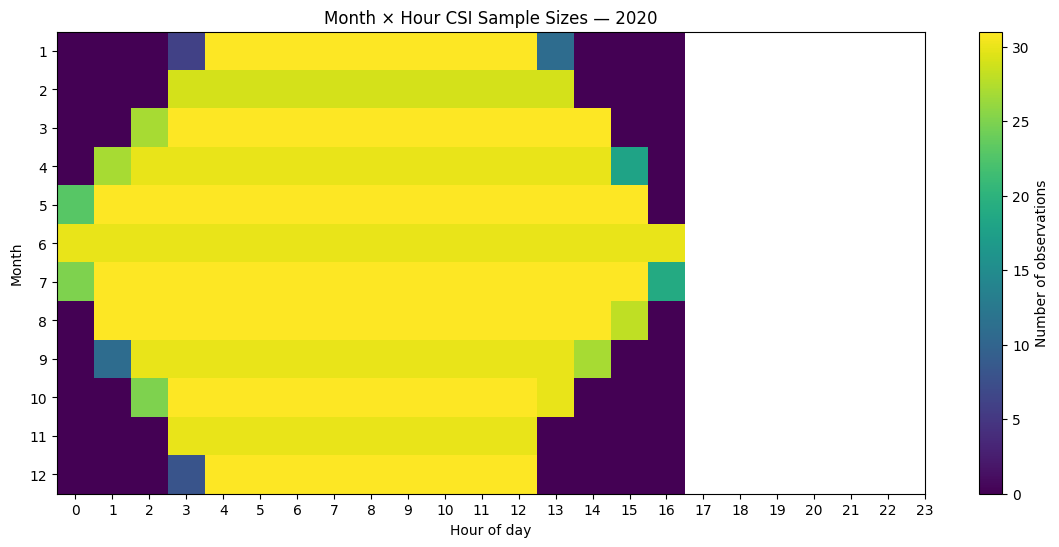

In [24]:
sample_size_matrix = (
    month_hour_counts
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 6))

plt.imshow(
    sample_size_matrix,
    aspect="auto"
)

plt.colorbar(label="Number of observations")

plt.xlabel("Hour of day")
plt.ylabel("Month")
plt.title("Month × Hour CSI Sample Sizes — 2020")

plt.xticks(
    range(24),
    range(24)
)

plt.yticks(
    range(12),
    range(1, 13)
)

plt.show()

## Global Versus Monthly Anomaly Classification

The global and month-conditioned approaches produce different anomaly thresholds.

The global method applies one threshold to the complete 2020 CSI distribution:

$$
T_g = Q_{0.10}(CSI)
$$

The monthly method estimates a separate threshold for each calendar month:

$$
T_m = Q_{0.10}(CSI \mid month=m)
$$

The two methods are now compared at the individual-observation level.

This comparison evaluates how often the choice of reference distribution changes the anomaly classification.

The purpose is not to determine which method is definitively correct, but to quantify the methodological sensitivity of anomaly identification.

In [26]:
global_q10 = analysis_df["csi"].quantile(0.10)

analysis_df["global_anomaly"] = (
    analysis_df["csi"] < global_q10
)

monthly_q10 = (
    analysis_df
    .groupby("month")["csi"]
    .transform("quantile", 0.10)
)

analysis_df["monthly_q10_threshold"] = monthly_q10

analysis_df["monthly_anomaly"] = (
    analysis_df["csi"] <
    analysis_df["monthly_q10_threshold"]
)

In [27]:
comparison = pd.crosstab(
    analysis_df["global_anomaly"],
    analysis_df["monthly_anomaly"],
    rownames=["Global anomaly"],
    colnames=["Monthly anomaly"]
)

print("========== GLOBAL VS MONTHLY ANOMALY ==========")
print(comparison)

========== GLOBAL VS MONTHLY ANOMALY ==========
Monthly anomaly  False  True 
Global anomaly               
False             4205     86
True                83    394


In [28]:
total = len(analysis_df)

both_anomaly = (
    analysis_df["global_anomaly"] &
    analysis_df["monthly_anomaly"]
).sum()

neither_anomaly = (
    ~analysis_df["global_anomaly"] &
    ~analysis_df["monthly_anomaly"]
).sum()

global_only = (
    analysis_df["global_anomaly"] &
    ~analysis_df["monthly_anomaly"]
).sum()

monthly_only = (
    ~analysis_df["global_anomaly"] &
    analysis_df["monthly_anomaly"]
).sum()

print("========== CLASSIFICATION AGREEMENT ==========")

print("Total observations:", total)
print("Both methods classify as anomaly:", both_anomaly)
print("Neither method classifies as anomaly:", neither_anomaly)
print("Global-only anomalies:", global_only)
print("Monthly-only anomalies:", monthly_only)

print(
    "\nAgreement percentage:",
    100 * (both_anomaly + neither_anomaly) / total
)

========== CLASSIFICATION AGREEMENT ==========
Total observations: 4768
Both methods classify as anomaly: 394
Neither method classifies as anomaly: 4205
Global-only anomalies: 83
Monthly-only anomalies: 86

Agreement percentage: 96.45553691275168


In [29]:
analysis_df["classification_difference"] = np.select(
    [
        analysis_df["global_anomaly"] &
        analysis_df["monthly_anomaly"],

        analysis_df["global_anomaly"] &
        ~analysis_df["monthly_anomaly"],

        ~analysis_df["global_anomaly"] &
        analysis_df["monthly_anomaly"]
    ],
    [
        "both_anomaly",
        "global_only",
        "monthly_only"
    ],
    default="neither"
)

In [30]:
difference_by_month = (
    analysis_df
    .groupby(
        ["month", "classification_difference"]
    )
    .size()
    .unstack(fill_value=0)
)

print("========== CLASSIFICATION DIFFERENCES BY MONTH ==========")
print(difference_by_month)

========== CLASSIFICATION DIFFERENCES BY MONTH ==========
classification_difference  both_anomaly  global_only  monthly_only  neither
month                                                                      
1                                    15            0            15      266
2                                    32           13             0      274
3                                    27            0            13      359
4                                    19            0            25      391
5                                    48            0             1      439
6                                    51           16             0      443
7                                    36            0            15      458
8                                    47            9             0      406
9                                    37            0             3      358
10                                   37           21             0      307
11                            

## Classification Differences by Hour

The global-versus-monthly comparison showed high overall agreement but identified a non-negligible subset of observations whose classification depends on the reference distribution.

The next analysis examines whether these classification differences are concentrated at particular hours of the day.

This provides evidence about whether the remaining disagreement may be associated with diurnal structure in addition to seasonal structure.

The analysis is descriptive and does not yet establish a final anomaly-detection method.

In [31]:
difference_by_hour = (
    analysis_df
    .groupby(
        ["hour", "classification_difference"]
    )
    .size()
    .unstack(fill_value=0)
)

print("========== CLASSIFICATION DIFFERENCES BY HOUR ==========")
print(difference_by_hour)

========== CLASSIFICATION DIFFERENCES BY HOUR ==========
classification_difference  both_anomaly  global_only  monthly_only  neither
hour                                                                       
3                                    16            0             0       62
4                                    26            1             1      133
5                                    45            6             5      179
6                                    45           12             5      256
7                                    40            8             8      310
8                                    40            7            10      309
9                                    40            8             8      310
10                                   29           10            10      317
11                                   17           10             9      330
12                                   11            6             7      342
13                             

In [32]:
hourly_difference_summary = (
    difference_by_hour
    .copy()
)

for column in [
    "both_anomaly",
    "global_only",
    "monthly_only",
    "neither"
]:
    if column not in hourly_difference_summary.columns:
        hourly_difference_summary[column] = 0

hourly_difference_summary["total"] = (
    hourly_difference_summary[
        [
            "both_anomaly",
            "global_only",
            "monthly_only",
            "neither"
        ]
    ].sum(axis=1)
)

hourly_difference_summary["disagreement"] = (
    hourly_difference_summary["global_only"] +
    hourly_difference_summary["monthly_only"]
)

hourly_difference_summary["disagreement_pct"] = (
    100 *
    hourly_difference_summary["disagreement"] /
    hourly_difference_summary["total"]
)

print(
    "========== HOURLY DISAGREEMENT SUMMARY =========="
)

print(hourly_difference_summary)

========== HOURLY DISAGREEMENT SUMMARY ==========
classification_difference  both_anomaly  global_only  monthly_only  neither  \
hour                                                                          
3                                    16            0             0       62   
4                                    26            1             1      133   
5                                    45            6             5      179   
6                                    45           12             5      256   
7                                    40            8             8      310   
8                                    40            7            10      309   
9                                    40            8             8      310   
10                                   29           10            10      317   
11                                   17           10             9      330   
12                                   11            6             7      342   
13

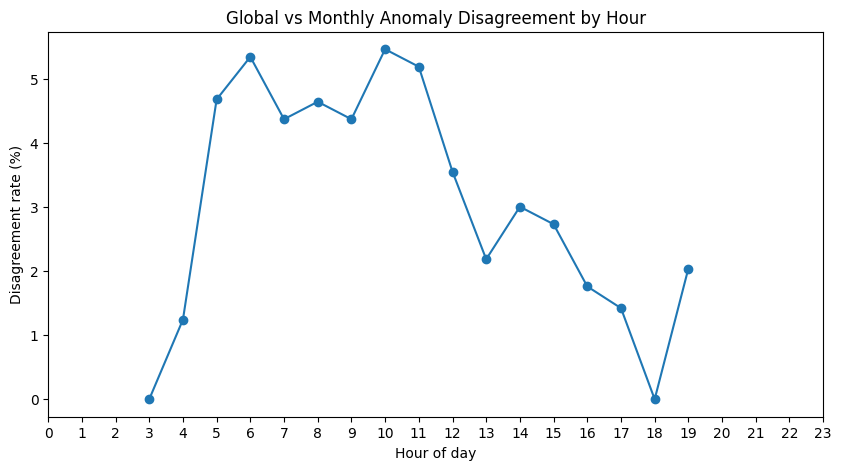

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_difference_summary.index,
    hourly_difference_summary["disagreement_pct"],
    marker="o"
)

plt.xlabel("Hour of day")
plt.ylabel("Disagreement rate (%)")
plt.title(
    "Global vs Monthly Anomaly Disagreement by Hour"
)

plt.xticks(range(24))

plt.show()

## Global Versus Monthly Threshold Sensitivity

The global and monthly-conditioned approaches produced different anomaly classifications for a subset of observations.

To understand the source of this disagreement, the corresponding threshold values are compared directly.

The global threshold is:

$$
T_g = Q_{0.10}(CSI)
$$

while the monthly threshold is:

$$
T_m = Q_{0.10}(CSI \mid month=m)
$$

The difference

$$
\Delta T_m = T_m - T_g
$$

measures how much the lower-tail reference for each month differs from the global reference.

A positive value indicates that the monthly 10th percentile is higher than the global threshold, while a negative value indicates that it is lower.

This analysis is descriptive and is used to understand methodological sensitivity rather than to establish a final anomaly threshold.

In [34]:
global_q10 = analysis_df["csi"].quantile(0.10)

monthly_thresholds = (
    analysis_df
    .groupby("month")["csi"]
    .quantile(0.10)
    .rename("monthly_q10")
    .to_frame()
)

monthly_thresholds["global_q10"] = global_q10

monthly_thresholds["threshold_difference"] = (
    monthly_thresholds["monthly_q10"]
    - monthly_thresholds["global_q10"]
)

monthly_thresholds["absolute_difference"] = (
    monthly_thresholds["threshold_difference"]
    .abs()
)

print("========== THRESHOLD SENSITIVITY ==========")
print(monthly_thresholds)

========== THRESHOLD SENSITIVITY ==========
       monthly_q10  global_q10  threshold_difference  absolute_difference
month                                                                    
1         0.263017    0.176348              0.086669             0.086669
2         0.166203    0.176348             -0.010145             0.010145
3         0.235646    0.176348              0.059298             0.059298
4         0.377937    0.176348              0.201589             0.201589
5         0.179271    0.176348              0.002923             0.002923
6         0.146312    0.176348             -0.030036             0.030036
7         0.227656    0.176348              0.051308             0.051308
8         0.152019    0.176348             -0.024329             0.024329
9         0.233039    0.176348              0.056691             0.056691
10        0.129641    0.176348             -0.046707             0.046707
11        0.409870    0.176348              0.233522             0.2

In [35]:
print("\n========== THRESHOLD DIFFERENCE SUMMARY ==========")

print(
    monthly_thresholds["threshold_difference"]
    .describe()
)

print(
    "\nLargest positive difference:",
    monthly_thresholds["threshold_difference"].max()
)

print(
    "Largest negative difference:",
    monthly_thresholds["threshold_difference"].min()
)

print(
    "Largest absolute difference:",
    monthly_thresholds["absolute_difference"].max()
)


========== THRESHOLD DIFFERENCE SUMMARY ==========
count    12.000000
mean      0.045963
std       0.091122
min      -0.046707
25%      -0.025553
50%       0.027115
75%       0.066141
max       0.233522
Name: threshold_difference, dtype: float64

Largest positive difference: 0.23352231798770848
Largest negative difference: -0.046707251509700703
Largest absolute difference: 0.23352231798770848


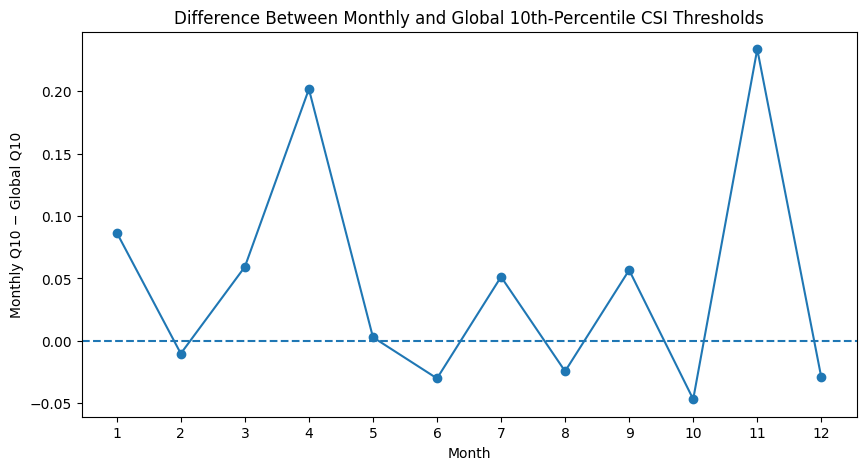

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_thresholds.index,
    monthly_thresholds["threshold_difference"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Month")
plt.ylabel("Monthly Q10 − Global Q10")
plt.title(
    "Difference Between Monthly and Global 10th-Percentile CSI Thresholds"
)

plt.xticks(range(1, 13))

plt.show()

## Threshold Sensitivity - Interpretation

The comparison between the global and monthly-conditioned 10th-percentile thresholds demonstrates substantial variation in the lower tail of the CSI distribution across months.

The global 2020 threshold was:

$$
T_g = 0.176348
$$

The monthly thresholds ranged from approximately 0.1296 in October to 0.4099 in November.

The difference between the monthly and global thresholds ranged from approximately -0.0467 to +0.2335 CSI units.

These differences demonstrate that the lower-tail distribution of CSI is not uniform across calendar months during the 2020 development period.

The result is consistent with the earlier analysis of anomaly rates. The global threshold produced monthly anomaly rates ranging from approximately 4.4% to 18.5%, whereas month-conditioned thresholds produced rates close to the nominal 10% within each month.

The global and monthly methods nevertheless agreed on 96.46% of individual CSI observations. Therefore, the primary methodological difference is not the overall number of observations classified as anomalous, but the seasonal allocation of those observations.

The month-and-hour analysis provided additional temporal conditioning but revealed that most month-hour groups contain only approximately 30 observations in the one-year development dataset, with some groups containing substantially fewer observations. Consequently, month-and-hour empirical thresholds are not considered sufficiently stable for final climatological anomaly identification using the current dataset.

These findings indicate that a final anomaly methodology should account for seasonal variation while avoiding overly granular empirical conditioning.

However, the current dataset contains only one complete calendar year. The thresholds derived here are therefore considered development estimates rather than climatological thresholds.

A longer multi-year historical record is required before selecting and validating the final anomaly reference distribution.

In [37]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [38]:
data_path = Path(
    "../data/interim/solar_historical_2015_2025_validated.csv"
)

df = pd.read_csv(data_path)

df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])

print("=" * 70)
print("VALIDATED HISTORICAL DATASET")
print("=" * 70)

print("\nPath:")
print(data_path)

print("\nExists:")
print(data_path.exists())

print("\nShape:")
print(df.shape)

print("\nTime range:")
print(df["start_time"].min())
print("to")
print(df["end_time"].max())

print("\nCSI observations:")
print(df["csi"].notna().sum())

print("\nNighttime observations:")
print(df["csi"].isna().sum())

print("=" * 70)

VALIDATED HISTORICAL DATASET

Path:
..\data\interim\solar_historical_2015_2025_validated.csv

Exists:
True

Shape:
(87696, 22)

Time range:
2015-01-01 00:00:00
to
2025-01-02 00:00:00

CSI observations:
47630

Nighttime observations:
40066


In [39]:
# Analytical population for CSI-based anomaly analysis

analysis_df = df[
    df["csi"].notna()
].copy()

analysis_df["year"] = analysis_df["start_time"].dt.year
analysis_df["month"] = analysis_df["start_time"].dt.month
analysis_df["hour"] = analysis_df["start_time"].dt.hour

print("=" * 70)
print("ANALYTICAL CSI POPULATION")
print("=" * 70)

print("\nObservations:", len(analysis_df))

print("\nYears:")
print(
    analysis_df["year"]
    .value_counts()
    .sort_index()
)

print("\nMonths:")
print(
    analysis_df["month"]
    .value_counts()
    .sort_index()
)

print("\nHours:")
print(
    analysis_df["hour"]
    .value_counts()
    .sort_index()
)

print("=" * 70)

ANALYTICAL CSI POPULATION

Observations: 47630

Years:
year
2015    4759
2016    4768
2017    4758
2018    4761
2019    4759
2020    4768
2021    4759
2022    4761
2023    4760
2024    4768
2025       9
Name: count, dtype: int64

Months:
month
1     2974
2     3113
3     3987
4     4340
5     4873
6     5097
7     5100
8     4625
9     3990
10    3661
11    3000
12    2870
Name: count, dtype: int64

Hours:
hour
3      778
4     1607
5     2354
6     3178
7     3654
8     3654
9     3654
10    3654
11    3654
12    3654
13    3654
14    3654
15    3654
16    2840
17    2114
18    1381
19     492
Name: count, dtype: int64


In [40]:
annual_csi = (
    analysis_df
    .groupby("year")["csi"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q05=lambda x: x.quantile(0.05),
        q10=lambda x: x.quantile(0.10),
        q20=lambda x: x.quantile(0.20),
        q25=lambda x: x.quantile(0.25),
    )
)

print("=" * 70)
print("ANNUAL CSI DISTRIBUTION")
print("=" * 70)

print(
    annual_csi.to_string(float_format=lambda x: f"{x:.6f}")
)

print("=" * 70)

ANNUAL CSI DISTRIBUTION
      count     mean   median      std      q05      q10      q20      q25
year                                                                      
2015   4759 0.706482 0.824412 0.310281 0.134231 0.199709 0.352351 0.425785
2016   4768 0.655653 0.728726 0.320681 0.127764 0.167268 0.288956 0.357210
2017   4758 0.681499 0.783861 0.318304 0.128344 0.166881 0.307511 0.384302
2018   4761 0.678022 0.760445 0.310494 0.136492 0.186115 0.330272 0.400740
2019   4759 0.666576 0.752048 0.326057 0.124808 0.158805 0.285840 0.359781
2020   4768 0.693169 0.796757 0.314844 0.131406 0.183357 0.329227 0.417831
2021   4759 0.684185 0.763238 0.311794 0.141610 0.199708 0.339487 0.402667
2022   4761 0.722105 0.841709 0.303848 0.144530 0.216968 0.388235 0.467800
2023   4760 0.672443 0.754033 0.315375 0.129385 0.173730 0.319767 0.385455
2024   4768 0.657664 0.720958 0.319066 0.133928 0.175020 0.294990 0.359337
2025      9 1.000000 1.000000 0.000000 1.000000 1.000000 1.000000 1.000000


In [41]:
monthly_csi = (
    analysis_df
    .groupby("month")["csi"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q05=lambda x: x.quantile(0.05),
        q10=lambda x: x.quantile(0.10),
        q20=lambda x: x.quantile(0.20),
        q25=lambda x: x.quantile(0.25),
    )
)

print("=" * 70)
print("MONTHLY CSI CLIMATOLOGY")
print("=" * 70)

print(
    monthly_csi.to_string(float_format=lambda x: f"{x:.6f}")
)

print("=" * 70)

MONTHLY CSI CLIMATOLOGY
       count     mean   median      std      q05      q10      q20      q25
month                                                                      
1       2974 0.691074 0.847110 0.340935 0.131161 0.161439 0.263516 0.345810
2       3113 0.690099 0.831787 0.335407 0.146671 0.174500 0.280466 0.340021
3       3987 0.689601 0.768279 0.317716 0.152872 0.205471 0.323591 0.380255
4       4340 0.666298 0.737355 0.300153 0.145029 0.194933 0.336949 0.394137
5       4873 0.563555 0.566557 0.296396 0.121403 0.147418 0.247523 0.294988
6       5097 0.662724 0.720656 0.304141 0.134051 0.198110 0.328723 0.398855
7       5100 0.706397 0.806130 0.300989 0.140311 0.210617 0.381957 0.467912
8       4625 0.713297 0.841536 0.307227 0.135329 0.215154 0.369985 0.443478
9       3990 0.715294 0.824616 0.303839 0.127560 0.219478 0.383553 0.462386
10      3661 0.708404 0.815721 0.305229 0.123217 0.187173 0.400201 0.472887
11      3000 0.709317 0.890625 0.332700 0.123249 0.142814 0.2990

In [42]:
# Use complete calendar years for climatological analysis

climatology_df = analysis_df[
    analysis_df["year"].between(2015, 2024)
].copy()

print("=" * 70)
print("CLIMATOLOGY POPULATION — COMPLETE YEARS ONLY")
print("=" * 70)

print("\nYears included:")
print(
    climatology_df["year"]
    .value_counts()
    .sort_index()
)

print("\nTotal observations:")
print(len(climatology_df))

print("\n2025 observations excluded from climatology:")
print(
    len(
        analysis_df[
            analysis_df["year"] == 2025
        ]
    )
)

print("=" * 70)

CLIMATOLOGY POPULATION — COMPLETE YEARS ONLY

Years included:
year
2015    4759
2016    4768
2017    4758
2018    4761
2019    4759
2020    4768
2021    4759
2022    4761
2023    4760
2024    4768
Name: count, dtype: int64

Total observations:
47621

2025 observations excluded from climatology:
9


In [43]:
# Month × hour sample sizes

month_hour_counts = (
    climatology_df
    .groupby(["month", "hour"])
    .size()
    .unstack(fill_value=0)
)

print("=" * 70)
print("MONTH × HOUR SAMPLE SIZES")
print("=" * 70)

print("\nMinimum group size:")
print(month_hour_counts.replace(0, np.nan).min().min())

print("\nMaximum group size:")
print(month_hour_counts.max().max())

print("\nNumber of observed month × hour groups:")
print(
    (month_hour_counts > 0).sum().sum()
)

print("\nGroups with fewer than 10 observations:")
print(
    (month_hour_counts > 0)
    .where(month_hour_counts < 10)
    .sum().sum()
)

print("\nGroups with fewer than 20 observations:")
print(
    (month_hour_counts > 0)
    .where(month_hour_counts < 20)
    .sum().sum()
)

print("\nGroups with fewer than 30 observations:")
print(
    (month_hour_counts > 0)
    .where(month_hour_counts < 30)
    .sum().sum()
)

print("\nFull month × hour table:")
print(month_hour_counts)

print("=" * 70)

MONTH × HOUR SAMPLE SIZES

Minimum group size:
65.0

Maximum group size:
310

Number of observed month × hour groups:
161

Groups with fewer than 10 observations:
0

Groups with fewer than 20 observations:
0

Groups with fewer than 30 observations:
0

Full month × hour table:
hour    3    4    5    6    7    8    9    10   11   12   13   14   15   16  \
month                                                                         
1        0    0    0   65  310  310  310  310  310  310  310  310  310  110   
2        0    0    0  283  283  283  283  283  283  283  283  283  283  283   
3        0    0  270  310  310  310  310  310  310  310  310  310  310  310   
4        0  264  300  300  300  300  300  300  300  300  300  300  300  300   
5      223  310  310  310  310  310  310  310  310  310  310  310  310  310   
6      300  300  300  300  300  300  300  300  300  300  300  300  300  300   
7      255  310  310  310  310  310  310  310  310  310  310  310  310  310   
8        0  

In [44]:
# Month × hour CSI distribution

month_hour_stats = (
    climatology_df
    .groupby(["month", "hour"])["csi"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        q05=lambda x: x.quantile(0.05),
        q10=lambda x: x.quantile(0.10),
        q20=lambda x: x.quantile(0.20),
    )
)

print("=" * 70)
print("MONTH × HOUR CSI DISTRIBUTION")
print("=" * 70)

print(
    month_hour_stats.to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)

print("=" * 70)

MONTH × HOUR CSI DISTRIBUTION
            count     mean   median      q05      q10      q20
month hour                                                    
1     6        65 0.847573 1.000000 0.161465 0.310768 0.662194
      7       310 0.732132 0.978905 0.153232 0.162296 0.377704
      8       310 0.716028 0.819897 0.134888 0.210059 0.347119
      9       310 0.683698 0.856501 0.118653 0.157851 0.233893
      10      310 0.673544 0.819157 0.123880 0.167198 0.249113
      11      310 0.642901 0.749693 0.104452 0.153133 0.208026
      12      310 0.621974 0.672373 0.102459 0.125976 0.197318
      13      310 0.641363 0.667766 0.116128 0.153824 0.250321
      14      310 0.694348 0.798954 0.163678 0.223422 0.314165
      15      310 0.757107 1.000000 0.150886 0.161652 0.394745
      16      110 0.732743 1.000000 0.149479 0.151833 0.167995
2     6       283 0.782891 0.993056 0.165669 0.187168 0.462394
      7       283 0.761725 0.885067 0.171530 0.296752 0.483149
      8       283 0.73130

## Low-Reference Sensitivity Analysis

The CSI metric is mathematically defined whenever clear-sky GHI is positive. However, observations with very small clear-sky reference values can be concentrated near temporal boundaries and may have greater sensitivity to small absolute measurement differences.

A diagnostic low-reference flag was defined during historical data validation as:

\[
0 < GHI_{clear} \leq 20\;Wh\,m^{-2}
\]

This threshold is used here only for sensitivity analysis. It is not treated as a physical drought threshold or as an automatic exclusion criterion.

The purpose of this analysis is to determine whether lower-tail CSI climatology is materially affected by low-reference observations.

In [45]:
# Low-reference sensitivity analysis

sensitivity_df = climatology_df.copy()

all_csi = sensitivity_df["csi"].dropna()

filtered_csi = sensitivity_df.loc[
    ~sensitivity_df["low_reference_flag"],
    "csi"
].dropna()

print("=" * 70)
print("LOW-REFERENCE CSI SENSITIVITY")
print("=" * 70)

print("\nAll positive-reference observations:")
print(f"Count: {len(all_csi)}")

print("\nExcluding low-reference observations:")
print(f"Count: {len(filtered_csi)}")

print("\nQuantile comparison:")

quantiles = [0.01, 0.05, 0.10, 0.20, 0.25, 0.50]

comparison = pd.DataFrame({
    "all_positive_reference": all_csi.quantile(quantiles),
    "exclude_low_reference": filtered_csi.quantile(quantiles)
})

comparison["absolute_difference"] = (
    comparison["exclude_low_reference"]
    - comparison["all_positive_reference"]
)

print(
    comparison.to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)

print("=" * 70)

LOW-REFERENCE CSI SENSITIVITY

All positive-reference observations:
Count: 47621

Excluding low-reference observations:
Count: 43040

Quantile comparison:
      all_positive_reference  exclude_low_reference  absolute_difference
0.01                0.088212               0.086443            -0.001770
0.05                0.132573               0.132041            -0.000532
0.10                0.179150               0.190270             0.011121
0.20                0.323003               0.322158            -0.000845
0.25                0.393482               0.386473            -0.007008
0.50                0.773006               0.753640            -0.019366


In [46]:
# Month × hour Q10 sensitivity

mh_all = (
    sensitivity_df
    .groupby(["month", "hour"])["csi"]
    .quantile(0.10)
    .rename("q10_all")
)

mh_filtered = (
    sensitivity_df.loc[
        ~sensitivity_df["low_reference_flag"]
    ]
    .groupby(["month", "hour"])["csi"]
    .quantile(0.10)
    .rename("q10_excluding_low_reference")
)

mh_sensitivity = pd.concat(
    [mh_all, mh_filtered],
    axis=1
)

mh_sensitivity["q10_difference"] = (
    mh_sensitivity["q10_excluding_low_reference"]
    - mh_sensitivity["q10_all"]
)

print("=" * 70)
print("MONTH × HOUR Q10 SENSITIVITY")
print("=" * 70)

print("\nLargest absolute Q10 changes:")

print(
    mh_sensitivity
    .assign(
        abs_difference=lambda x:
            x["q10_difference"].abs()
    )
    .sort_values(
        "abs_difference",
        ascending=False
    )
    .head(20)
    .to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)

print("=" * 70)


MONTH × HOUR Q10 SENSITIVITY

Largest absolute Q10 changes:
            q10_all  q10_excluding_low_reference  q10_difference  abs_difference
month hour                                                                      
3     17   0.163752                     0.487781        0.324029        0.324029
9     17   0.834403                     0.527400       -0.307003        0.307003
8     18   0.372402                     0.237375       -0.135027        0.135027
2     6    0.187168                     0.303619        0.116451        0.116451
10    16   0.956956                     0.867165       -0.089790        0.089790
      5    0.124037                     0.207842        0.083805        0.083805
5     18   0.603896                     0.632192        0.028295        0.028295
11    15   0.945382                     0.926988       -0.018394        0.018394
8     4    0.133776                     0.144697        0.010921        0.010921
11    6    0.133632                     0.126543 

## Month × Hour Threshold Stability and Low-Reference Composition

The sensitivity analysis showed that some month × hour lower-tail estimates change substantially when low-reference observations are excluded.

This section examines whether these changes are associated with the proportion of low-reference observations within each month × hour group.

The purpose is diagnostic: to determine whether instability is concentrated in groups with substantial low-reference representation.

In [47]:
# Month × hour composition and threshold stability

mh_composition = (
    sensitivity_df
    .groupby(["month", "hour"])
    .agg(
        count=("csi", "count"),
        low_reference_count=("low_reference_flag", "sum")
    )
)

mh_composition["low_reference_fraction"] = (
    mh_composition["low_reference_count"]
    / mh_composition["count"]
)

mh_analysis = mh_sensitivity.join(
    mh_composition
)

mh_analysis["abs_q10_difference"] = (
    mh_analysis["q10_difference"].abs()
)

print("=" * 70)
print("MONTH × HOUR THRESHOLD STABILITY")
print("=" * 70)

print("\nGroups with largest Q10 changes:")

print(
    mh_analysis
    .sort_values(
        "abs_q10_difference",
        ascending=False
    )
    .head(20)
    .to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)

print("=" * 70)

MONTH × HOUR THRESHOLD STABILITY

Groups with largest Q10 changes:
            q10_all  q10_excluding_low_reference  q10_difference  count  low_reference_count  low_reference_fraction  abs_q10_difference
month hour                                                                                                                              
3     17   0.163752                     0.487781        0.324029    307                  251                0.817590            0.324029
9     17   0.834403                     0.527400       -0.307003    277                  182                0.657040            0.307003
8     18   0.372402                     0.237375       -0.135027    285                  231                0.810526            0.135027
2     6    0.187168                     0.303619        0.116451    283                  181                0.639576            0.116451
10    16   0.956956                     0.867165       -0.089790    307                  204                0.6

In [48]:
# Relationship between low-reference composition and Q10 sensitivity

valid_relationship = mh_analysis.dropna(
    subset=[
        "low_reference_fraction",
        "abs_q10_difference"
    ]
)

print("=" * 70)
print("LOW-REFERENCE FRACTION vs Q10 SENSITIVITY")
print("=" * 70)

print("\nCorrelation:")
print(
    valid_relationship[
        [
            "low_reference_fraction",
            "abs_q10_difference"
        ]
    ].corr()
)

print("\nLow-reference fraction summary:")
print(
    valid_relationship[
        "low_reference_fraction"
    ].describe()
)

print("\nQ10 absolute-difference summary:")
print(
    valid_relationship[
        "abs_q10_difference"
    ].describe()
)

print("=" * 70)

LOW-REFERENCE FRACTION vs Q10 SENSITIVITY

Correlation:
                        low_reference_fraction  abs_q10_difference
low_reference_fraction                1.000000            0.672967
abs_q10_difference                    0.672967            1.000000

Low-reference fraction summary:
count    150.000000
mean       0.057206
std        0.190976
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.992126
Name: low_reference_fraction, dtype: float64

Q10 absolute-difference summary:
count    150.000000
mean       0.007571
std        0.040042
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.324029
Name: abs_q10_difference, dtype: float64


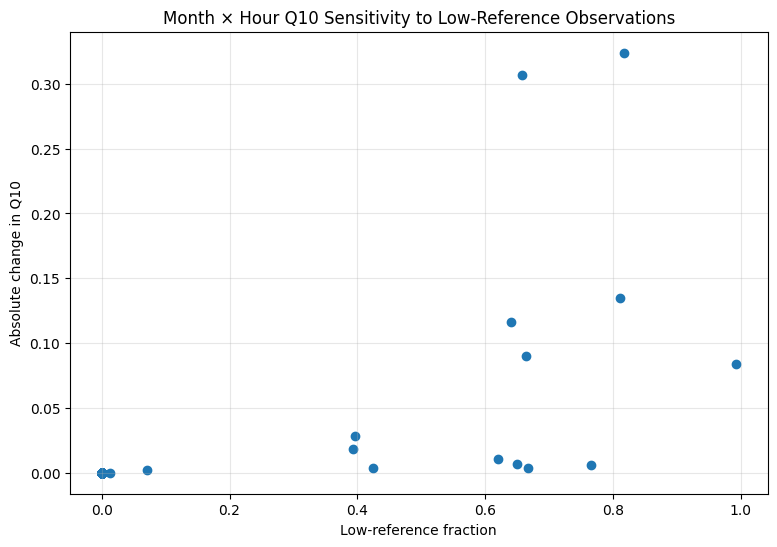

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    valid_relationship["low_reference_fraction"],
    valid_relationship["abs_q10_difference"]
)

plt.xlabel("Low-reference fraction")
plt.ylabel("Absolute change in Q10")
plt.title(
    "Month × Hour Q10 Sensitivity to Low-Reference Observations"
)

plt.grid(True, alpha=0.3)
plt.show()

## Candidate Anomaly Baselines

Three candidate climatological baselines are evaluated:

1. Global Q10: a single lower-tail threshold across the complete climatological population.
2. Monthly Q10: a separate lower-tail threshold for each calendar month.
3. Month × hour Q10: a separate lower-tail threshold for each observed month × hour combination.

The comparison is performed using leave-one-year-out climatology. For each evaluation year, that year's observations are excluded from the climatological baseline and the resulting threshold is applied to the held-out year.

This prevents the evaluated year's observations from contributing directly to its own anomaly threshold.

In [50]:
# Complete-year evaluation population

evaluation_df = climatology_df.copy()

evaluation_years = sorted(
    evaluation_df["year"].unique()
)

print("=" * 70)
print("LEAVE-ONE-YEAR-OUT EVALUATION")
print("=" * 70)

print("\nEvaluation years:")
print(evaluation_years)

print("\nNumber of evaluation years:")
print(len(evaluation_years))

print("\nTotal CSI observations:")
print(len(evaluation_df))

print("=" * 70)

LEAVE-ONE-YEAR-OUT EVALUATION

Evaluation years:
[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]

Number of evaluation years:
10

Total CSI observations:
47621


In [51]:
# Leave-one-year-out candidate thresholds

threshold_records = []

for held_out_year in evaluation_years:

    training_df = evaluation_df[
        evaluation_df["year"] != held_out_year
    ].copy()

    # Global Q10
    global_q10 = training_df["csi"].quantile(0.10)

    # Monthly Q10
    monthly_q10 = (
        training_df
        .groupby("month")["csi"]
        .quantile(0.10)
    )

    # Month × hour Q10
    month_hour_q10 = (
        training_df
        .groupby(["month", "hour"])["csi"]
        .quantile(0.10)
    )

    threshold_records.append({
        "held_out_year": held_out_year,
        "global_q10": global_q10,
        "monthly_q10": monthly_q10,
        "month_hour_q10": month_hour_q10
    })

print("=" * 70)
print("LEAVE-ONE-YEAR-OUT THRESHOLDS CREATED")
print("=" * 70)

print(f"\nYears evaluated: {len(threshold_records)}")

print("=" * 70)

LEAVE-ONE-YEAR-OUT THRESHOLDS CREATED

Years evaluated: 10


In [53]:
# Evaluate candidate anomaly baselines on held-out years

evaluation_results = []

for record in threshold_records:

    held_out_year = record["held_out_year"]

    test_df = evaluation_df[
        evaluation_df["year"] == held_out_year
    ].copy()

    # --------------------------------------------------
    # Candidate A: Global Q10
    # --------------------------------------------------

    global_threshold = record["global_q10"]

    test_df["global_threshold"] = global_threshold

    test_df["global_anomaly"] = (
        test_df["csi"] < test_df["global_threshold"]
    )

    # --------------------------------------------------
    # Candidate B: Monthly Q10
    # --------------------------------------------------

    monthly_thresholds = record["monthly_q10"]

    test_df["monthly_threshold"] = (
        test_df["month"].map(monthly_thresholds)
    )

    test_df["monthly_anomaly"] = (
        test_df["csi"]
        < test_df["monthly_threshold"]
    )

    # --------------------------------------------------
    # Candidate C: Month × hour Q10
    # --------------------------------------------------

    month_hour_thresholds = record["month_hour_q10"]

    test_df["month_hour_threshold"] = [
        month_hour_thresholds.get(
            (month, hour),
            np.nan
        )
        for month, hour in zip(
            test_df["month"],
            test_df["hour"]
        )
    ]

    test_df["month_hour_anomaly"] = (
        test_df["csi"]
        < test_df["month_hour_threshold"]
    )

    # --------------------------------------------------
    # Store results
    # --------------------------------------------------

    evaluation_results.append(
        test_df[
            [
                "year",
                "month",
                "hour",
                "csi",
                "global_threshold",
                "global_anomaly",
                "monthly_threshold",
                "monthly_anomaly",
                "month_hour_threshold",
                "month_hour_anomaly"
            ]
        ].assign(
            held_out_year=held_out_year
        )
    )

evaluation_results_df = pd.concat(
    evaluation_results,
    ignore_index=True
)

print("=" * 70)
print("HELD-OUT ANOMALY EVALUATION COMPLETE")
print("=" * 70)

print("\nShape:")
print(evaluation_results_df.shape)

print("\nColumns:")
print(evaluation_results_df.columns.tolist())

print("\nHeld-out years:")
print(
    evaluation_results_df["held_out_year"]
    .unique()
)

print("=" * 70)

HELD-OUT ANOMALY EVALUATION COMPLETE

Shape:
(47621, 11)

Columns:
['year', 'month', 'hour', 'csi', 'global_threshold', 'global_anomaly', 'monthly_threshold', 'monthly_anomaly', 'month_hour_threshold', 'month_hour_anomaly', 'held_out_year']

Held-out years:
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]


In [54]:
# Overall held-out anomaly rates

anomaly_summary = pd.DataFrame({
    "global_q10": [
        evaluation_results_df["global_anomaly"].mean()
    ],
    "monthly_q10": [
        evaluation_results_df["monthly_anomaly"].mean()
    ],
    "month_hour_q10": [
        evaluation_results_df["month_hour_anomaly"].mean()
    ]
})

print("=" * 70)
print("HELD-OUT ANOMALY RATES")
print("=" * 70)

print(
    anomaly_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("=" * 70)

HELD-OUT ANOMALY RATES
 global_q10  monthly_q10  month_hour_q10
     0.1000       0.1016          0.1044


In [56]:
# Year-by-year held-out anomaly rates

yearly_anomaly_rates = (
    evaluation_results_df
    .groupby("held_out_year")
    .agg(
        global_q10=("global_anomaly", "mean"),
        monthly_q10=("monthly_anomaly", "mean"),
        month_hour_q10=("month_hour_anomaly", "mean")
    )
)

print("=" * 70)
print("YEAR-BY-YEAR HELD-OUT ANOMALY RATES")
print("=" * 70)

print(
    yearly_anomaly_rates.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)

print("=" * 70)

YEAR-BY-YEAR HELD-OUT ANOMALY RATES
               global_q10  monthly_q10  month_hour_q10
held_out_year                                         
2015               0.0874       0.0872          0.0927
2016               0.1103       0.1130          0.1200
2017               0.1097       0.1116          0.1181
2018               0.0966       0.1002          0.0985
2019               0.1269       0.1227          0.1248
2020               0.0973       0.1030          0.1065
2021               0.0868       0.0878          0.0880
2022               0.0762       0.0752          0.0758
2023               0.1036       0.1044          0.1040
2024               0.1051       0.1109          0.1156


In [57]:
# Stability statistics across held-out years

stability_summary = pd.DataFrame({
    "mean_anomaly_rate": yearly_anomaly_rates.mean(),
    "std_anomaly_rate": yearly_anomaly_rates.std(),
    "min_anomaly_rate": yearly_anomaly_rates.min(),
    "max_anomaly_rate": yearly_anomaly_rates.max(),
    "range": (
        yearly_anomaly_rates.max()
        - yearly_anomaly_rates.min()
    ),
    "mean_abs_deviation_from_10pct": (
        yearly_anomaly_rates
        .sub(0.10)
        .abs()
        .mean()
    )
})

print("=" * 70)
print("ANOMALY-RATE STABILITY ACROSS HELD-OUT YEARS")
print("=" * 70)

print(
    stability_summary.to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)

print("=" * 70)

ANOMALY-RATE STABILITY ACROSS HELD-OUT YEARS
                mean_anomaly_rate  std_anomaly_rate  min_anomaly_rate  max_anomaly_rate    range  mean_abs_deviation_from_10pct
global_q10               0.099997          0.014453          0.076244          0.126917 0.050673                       0.011122
monthly_q10              0.101612          0.014415          0.075194          0.122715 0.047521                       0.011566
month_hour_q10           0.104404          0.015752          0.075824          0.124816 0.048992                       0.013395


In [58]:
# Verify month × hour threshold coverage in held-out evaluation

missing_mh_thresholds = (
    evaluation_results_df["month_hour_threshold"]
    .isna()
)

print("=" * 70)
print("MONTH × HOUR THRESHOLD COVERAGE")
print("=" * 70)

print("\nObservations without a month × hour threshold:")
print(
    missing_mh_thresholds.sum()
)

print("\nPercentage without threshold:")
print(
    100 * missing_mh_thresholds.mean()
)

print("\nObservations with a month × hour threshold:")
print(
    (~missing_mh_thresholds).sum()
)

print("=" * 70)

MONTH × HOUR THRESHOLD COVERAGE

Observations without a month × hour threshold:
0

Percentage without threshold:
0.0

Observations with a month × hour threshold:
47621


## Temporal Persistence of Candidate Anomalies

A solar energy drought is not defined solely by an individual low-availability observation. Persistence is therefore examined by grouping consecutive anomalous observations into temporal runs.

For each candidate anomaly baseline, consecutive anomalous hourly observations are identified within each held-out year.

Run-level characteristics include:

- number of anomaly runs,
- run duration,
- total anomalous hours,
- number of short isolated anomalies,
- number of persistent anomaly episodes,
- and maximum run duration.

This analysis is descriptive and is used to assess how each candidate climatological baseline translates point anomalies into temporally persistent episodes.

In [59]:
def identify_anomaly_runs(df, anomaly_column):
    """
    Identify consecutive anomalous hourly observations.

    Runs are evaluated within each held-out year.
    """

    data = df.sort_values(
        ["held_out_year", "year", "month", "hour"]
    ).copy()

    # Ensure chronological ordering
    data = data.sort_values(
        "csi"  # temporary; replaced below
    )

In [60]:
# Verify timestamp availability in the original evaluation population

print("=" * 70)
print("EVALUATION TIMESTAMP CHECK")
print("=" * 70)

print("\nEvaluation dataframe columns:")
print(
    evaluation_df.columns.tolist()
)

print("\nTimestamp columns:")
print(
    [
        col
        for col in evaluation_df.columns
        if "time" in col.lower()
    ]
)

print("=" * 70)

EVALUATION TIMESTAMP CHECK

Evaluation dataframe columns:
['observation_period', 'toa', 'clear_sky_ghi', 'clear_sky_bhi', 'clear_sky_dhi', 'clear_sky_bni', 'ghi', 'bhi', 'dhi', 'bni', 'reliability', 'start_time', 'end_time', 'ghi_component_difference', 'solar_period', 'ghi_above_clear', 'bhi_above_clear', 'dhi_above_clear', 'bni_above_clear', 'csi', 'ghi_reconstructed', 'low_reference_flag', 'year', 'month', 'hour']

Timestamp columns:
['start_time', 'end_time']


In [64]:
# Rebuild held-out evaluation results with timestamps

evaluation_results_with_time = []

for record in threshold_records:

    held_out_year = record["held_out_year"]

    test_df = evaluation_df[
        evaluation_df["year"] == held_out_year
    ].copy()

    # Explicitly store which year is being held out
    test_df["held_out_year"] = held_out_year

    # --------------------------------------------------
    # Candidate A: Global Q10
    # --------------------------------------------------

    global_threshold = record["global_q10"]

    test_df["global_threshold"] = global_threshold

    test_df["global_anomaly"] = (
        test_df["csi"] < test_df["global_threshold"]
    )

    # --------------------------------------------------
    # Candidate B: Monthly Q10
    # --------------------------------------------------

    monthly_thresholds = record["monthly_q10"]

    test_df["monthly_threshold"] = (
        test_df["month"].map(monthly_thresholds)
    )

    test_df["monthly_anomaly"] = (
        test_df["csi"]
        < test_df["monthly_threshold"]
    )

    # --------------------------------------------------
    # Candidate C: Month × hour Q10
    # --------------------------------------------------

    month_hour_thresholds = record["month_hour_q10"]

    test_df["month_hour_threshold"] = [
        month_hour_thresholds.get(
            (month, hour),
            np.nan
        )
        for month, hour in zip(
            test_df["month"],
            test_df["hour"]
        )
    ]

    test_df["month_hour_anomaly"] = (
        test_df["csi"]
        < test_df["month_hour_threshold"]
    )

    # --------------------------------------------------
    # Keep original timestamps and results
    # --------------------------------------------------

    evaluation_results_with_time.append(
        test_df[
            [
                "held_out_year",
                "start_time",
                "end_time",
                "year",
                "month",
                "hour",
                "csi",
                "global_threshold",
                "global_anomaly",
                "monthly_threshold",
                "monthly_anomaly",
                "month_hour_threshold",
                "month_hour_anomaly"
            ]
        ]
    )

evaluation_results_df = pd.concat(
    evaluation_results_with_time,
    ignore_index=True
)

print("=" * 70)
print("HELD-OUT EVALUATION WITH TIMESTAMPS")
print("=" * 70)

print("\nShape:")
print(evaluation_results_df.shape)

print("\nMissing start_time:")
print(
    evaluation_results_df["start_time"].isna().sum()
)

print("\nMissing end_time:")
print(
    evaluation_results_df["end_time"].isna().sum()
)

print("\nDuplicate held-out year + timestamp:")
print(
    evaluation_results_df.duplicated(
        subset=["held_out_year", "start_time"]
    ).sum()
)

print("\nHeld-out year counts:")
print(
    evaluation_results_df["held_out_year"]
    .value_counts()
    .sort_index()
)

print("=" * 70)

HELD-OUT EVALUATION WITH TIMESTAMPS

Shape:
(47621, 13)

Missing start_time:
0

Missing end_time:
0

Duplicate held-out year + timestamp:
0

Held-out year counts:
held_out_year
2015    4759
2016    4768
2017    4758
2018    4761
2019    4759
2020    4768
2021    4759
2022    4761
2023    4760
2024    4768
Name: count, dtype: int64


In [65]:
def identify_anomaly_runs(df, anomaly_column):
    """
    Identify consecutive hourly anomaly runs.

    A run continues only when:
    1. Current observation is anomalous
    2. Previous observation is anomalous
    3. Actual timestamps are exactly one hour apart
    4. Observations belong to the same held-out year
    """

    data = df[
        [
            "held_out_year",
            "start_time",
            "end_time",
            "csi",
            anomaly_column
        ]
    ].copy()

    # Sort chronologically within each held-out year
    data = data.sort_values(
        ["held_out_year", "start_time"]
    ).reset_index(drop=True)

    # Previous timestamp
    data["previous_time"] = (
        data.groupby("held_out_year")["start_time"]
        .shift(1)
    )

    # Actual time difference
    data["time_gap"] = (
        data["start_time"]
        - data["previous_time"]
    )

    # Previous anomaly status
    data["previous_anomaly"] = (
        data.groupby("held_out_year")[anomaly_column]
        .shift(1)
        .fillna(False)
        .astype(bool)
    )

    # Does this anomaly continue the previous run?
    data["continues_run"] = (
        data[anomaly_column]
        & data["previous_anomaly"]
        & (
            data["time_gap"]
            == pd.Timedelta(hours=1)
        )
    )

    # Start of a new anomaly run
    data["new_run"] = (
        data[anomaly_column]
        & ~data["continues_run"]
    )

    # Unique run identifier
    data["run_id"] = data["new_run"].cumsum()

    # Keep only anomalous observations
    anomaly_data = data[
        data[anomaly_column]
    ].copy()

    # Summarize each run
    runs = (
        anomaly_data
        .groupby(
            ["held_out_year", "run_id"],
            as_index=False
        )
        .agg(
            start_time=("start_time", "min"),
            end_time=("end_time", "max"),
            duration_hours=("start_time", "size"),
            min_csi=("csi", "min"),
            mean_csi=("csi", "mean")
        )
    )

    return runs

In [66]:
global_runs = identify_anomaly_runs(
    evaluation_results_df,
    "global_anomaly"
)

monthly_runs = identify_anomaly_runs(
    evaluation_results_df,
    "monthly_anomaly"
)

month_hour_runs = identify_anomaly_runs(
    evaluation_results_df,
    "month_hour_anomaly"
)

print("=" * 70)
print("ANOMALY RUN DETECTION")
print("=" * 70)

print("\nGlobal Q10 runs:", len(global_runs))
print("Monthly Q10 runs:", len(monthly_runs))
print("Month × hour Q10 runs:", len(month_hour_runs))

print("\nGlobal Q10:")
display(global_runs.head(10))

print("\nMonthly Q10:")
display(monthly_runs.head(10))

print("\nMonth × hour Q10:")
display(month_hour_runs.head(10))

ANOMALY RUN DETECTION

Global Q10 runs: 2282
Monthly Q10 runs: 2273
Month × hour Q10 runs: 2268

Global Q10:


C:\Users\Admin\AppData\Local\Temp\ipykernel_7356\818674481.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_7356\818674481.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_7356\818674481.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_sile

,held_out_year,run_id,start_time,end_time,duration_hours,min_csi,mean_csi
0,2015,1,2015-01-03 13:00:00,2015-01-03 14:00:00,1,0.117226,0.117226
1,2015,2,2015-01-09 07:00:00,2015-01-09 08:00:00,1,0.162049,0.162049
2,2015,3,2015-01-09 09:00:00,2015-01-09 10:00:00,1,0.176945,0.176945
3,2015,4,2015-01-09 11:00:00,2015-01-09 14:00:00,3,0.102484,0.119058
4,2015,5,2015-01-11 07:00:00,2015-01-11 10:00:00,3,0.134399,0.145625
5,2015,6,2015-01-12 09:00:00,2015-01-12 10:00:00,1,0.152402,0.152402
6,2015,7,2015-01-14 07:00:00,2015-01-14 08:00:00,1,0.161764,0.161764
7,2015,8,2015-01-14 12:00:00,2015-01-14 14:00:00,2,0.099193,0.110814
8,2015,9,2015-01-16 07:00:00,2015-01-16 08:00:00,1,0.149356,0.149356
9,2015,10,2015-01-16 10:00:00,2015-01-16 13:00:00,3,0.102922,0.136881



Monthly Q10:


,held_out_year,run_id,start_time,end_time,duration_hours,min_csi,mean_csi
0,2015,1,2015-01-03 13:00:00,2015-01-03 14:00:00,1,0.117226,0.117226
1,2015,2,2015-01-09 11:00:00,2015-01-09 14:00:00,3,0.102484,0.119058
2,2015,3,2015-01-11 08:00:00,2015-01-11 10:00:00,2,0.134399,0.137924
3,2015,4,2015-01-12 09:00:00,2015-01-12 10:00:00,1,0.152402,0.152402
4,2015,5,2015-01-14 12:00:00,2015-01-14 14:00:00,2,0.099193,0.110814
5,2015,6,2015-01-16 07:00:00,2015-01-16 08:00:00,1,0.149356,0.149356
6,2015,7,2015-01-16 11:00:00,2015-01-16 13:00:00,2,0.102922,0.116688
7,2015,8,2015-01-17 09:00:00,2015-01-17 10:00:00,1,0.146306,0.146306
8,2015,9,2015-01-17 12:00:00,2015-01-17 13:00:00,1,0.127792,0.127792
9,2015,10,2015-01-17 15:00:00,2015-01-17 16:00:00,1,0.150791,0.150791



Month × hour Q10:


,held_out_year,run_id,start_time,end_time,duration_hours,min_csi,mean_csi
0,2015,1,2015-01-03 13:00:00,2015-01-03 14:00:00,1,0.117226,0.117226
1,2015,2,2015-01-09 07:00:00,2015-01-09 08:00:00,1,0.162049,0.162049
2,2015,3,2015-01-09 11:00:00,2015-01-09 14:00:00,3,0.102484,0.119058
3,2015,4,2015-01-11 07:00:00,2015-01-11 10:00:00,3,0.134399,0.145625
4,2015,5,2015-01-12 09:00:00,2015-01-12 10:00:00,1,0.152402,0.152402
5,2015,6,2015-01-14 07:00:00,2015-01-14 08:00:00,1,0.161764,0.161764
6,2015,7,2015-01-14 12:00:00,2015-01-14 14:00:00,2,0.099193,0.110814
7,2015,8,2015-01-16 07:00:00,2015-01-16 08:00:00,1,0.149356,0.149356
8,2015,9,2015-01-16 11:00:00,2015-01-16 13:00:00,2,0.102922,0.116688
9,2015,10,2015-01-17 09:00:00,2015-01-17 10:00:00,1,0.146306,0.146306


In [67]:
def summarize_runs(runs):

    return pd.Series({
        "number_of_runs": len(runs),
        "total_anomalous_hours": runs["duration_hours"].sum(),
        "mean_duration_hours": runs["duration_hours"].mean(),
        "median_duration_hours": runs["duration_hours"].median(),
        "max_duration_hours": runs["duration_hours"].max(),
        "runs_1h": (runs["duration_hours"] == 1).sum(),
        "runs_2h": (runs["duration_hours"] == 2).sum(),
        "runs_3plus": (runs["duration_hours"] >= 3).sum(),
        "runs_6plus": (runs["duration_hours"] >= 6).sum(),
        "runs_12plus": (runs["duration_hours"] >= 12).sum(),
        "runs_24plus": (runs["duration_hours"] >= 24).sum()
    })


persistence_summary = pd.DataFrame({
    "global_q10": summarize_runs(global_runs),
    "monthly_q10": summarize_runs(monthly_runs),
    "month_hour_q10": summarize_runs(month_hour_runs)
}).T

print("=" * 70)
print("PERSISTENCE SUMMARY")
print("=" * 70)

display(persistence_summary)

PERSISTENCE SUMMARY


,number_of_runs,total_anomalous_hours,mean_duration_hours,median_duration_hours,max_duration_hours,runs_1h,runs_2h,runs_3plus,runs_6plus,runs_12plus,runs_24plus
global_q10,2282.0,4762.0,2.086766,1.0,14.0,1166.0,526.0,590.0,116.0,4.0,0.0
monthly_q10,2273.0,4839.0,2.128905,1.0,14.0,1138.0,527.0,608.0,120.0,3.0,0.0
month_hour_q10,2268.0,4972.0,2.192240,1.0,16.0,1145.0,531.0,592.0,158.0,6.0,0.0


In [68]:
def yearly_run_summary(runs):

    summary = (
        runs
        .groupby("held_out_year")
        .agg(
            number_of_runs=("run_id", "count"),
            total_anomalous_hours=("duration_hours", "sum"),
            mean_duration_hours=("duration_hours", "mean"),
            median_duration_hours=("duration_hours", "median"),
            max_duration_hours=("duration_hours", "max"),
            runs_1h=("duration_hours", lambda x: (x == 1).sum()),
            runs_2h=("duration_hours", lambda x: (x == 2).sum()),
            runs_3plus=("duration_hours", lambda x: (x >= 3).sum()),
            runs_6plus=("duration_hours", lambda x: (x >= 6).sum()),
            runs_12plus=("duration_hours", lambda x: (x >= 12).sum()),
            runs_24plus=("duration_hours", lambda x: (x >= 24).sum())
        )
        .reset_index()
    )

    summary["fraction_3plus"] = (
        summary["runs_3plus"]
        / summary["number_of_runs"]
    )

    summary["fraction_6plus"] = (
        summary["runs_6plus"]
        / summary["number_of_runs"]
    )

    return summary

In [69]:
global_yearly = yearly_run_summary(global_runs)
monthly_yearly = yearly_run_summary(monthly_runs)
month_hour_yearly = yearly_run_summary(month_hour_runs)

print("=" * 80)
print("GLOBAL Q10 — YEARLY PERSISTENCE")
print("=" * 80)

display(global_yearly)

print("=" * 80)
print("MONTHLY Q10 — YEARLY PERSISTENCE")
print("=" * 80)

display(monthly_yearly)

print("=" * 80)
print("MONTH × HOUR Q10 — YEARLY PERSISTENCE")
print("=" * 80)

display(month_hour_yearly)

GLOBAL Q10 — YEARLY PERSISTENCE


,held_out_year,number_of_runs,total_anomalous_hours,mean_duration_hours,median_duration_hours,max_duration_hours,runs_1h,runs_2h,runs_3plus,runs_6plus,runs_12plus,runs_24plus,fraction_3plus,fraction_6plus
0,2015,190,416,2.189474,1.0,12,99,39,52,12,1,0,0.273684,0.063158
1,2016,259,526,2.030888,1.0,10,131,63,65,10,0,0,0.250965,0.038610
2,2017,242,522,2.157025,2.0,9,115,57,70,8,0,0,0.289256,0.033058
3,2018,222,460,2.072072,1.0,10,119,50,53,13,0,0,0.238739,0.058559
4,2019,269,604,2.245353,2.0,9,122,65,82,17,0,0,0.304833,0.063197
5,2020,207,464,2.241546,2.0,14,99,52,56,19,1,0,0.270531,0.091787
6,2021,223,413,1.852018,1.0,6,121,57,45,5,0,0,0.201794,0.022422
7,2022,194,363,1.871134,1.0,7,101,48,45,4,0,0,0.231959,0.020619
8,2023,238,493,2.071429,1.0,9,130,46,62,13,0,0,0.260504,0.054622
9,2024,238,501,2.105042,1.0,13,129,49,60,15,2,0,0.252101,0.063025


MONTHLY Q10 — YEARLY PERSISTENCE


,held_out_year,number_of_runs,total_anomalous_hours,mean_duration_hours,median_duration_hours,max_duration_hours,runs_1h,runs_2h,runs_3plus,runs_6plus,runs_12plus,runs_24plus,fraction_3plus,fraction_6plus
0,2015,188,415,2.207447,2.0,12,91,51,46,12,1,0,0.244681,0.063830
1,2016,261,539,2.065134,2.0,10,130,63,68,11,0,0,0.260536,0.042146
2,2017,234,531,2.269231,2.0,9,113,46,75,14,0,0,0.320513,0.059829
3,2018,228,477,2.092105,1.0,11,117,55,56,14,0,0,0.245614,0.061404
4,2019,257,584,2.272374,2.0,9,113,58,86,15,0,0,0.334630,0.058366
5,2020,212,491,2.316038,2.0,14,99,50,63,17,1,0,0.297170,0.080189
6,2021,217,418,1.926267,1.0,9,118,55,44,7,0,0,0.202765,0.032258
7,2022,194,358,1.845361,1.0,7,105,43,46,2,0,0,0.237113,0.010309
8,2023,245,497,2.028571,1.0,9,135,51,59,13,0,0,0.240816,0.053061
9,2024,237,529,2.232068,2.0,12,117,55,65,15,1,0,0.274262,0.063291


MONTH × HOUR Q10 — YEARLY PERSISTENCE


,held_out_year,number_of_runs,total_anomalous_hours,mean_duration_hours,median_duration_hours,max_duration_hours,runs_1h,runs_2h,runs_3plus,runs_6plus,runs_12plus,runs_24plus,fraction_3plus,fraction_6plus
0,2015,207,441,2.130435,1.0,12,117,34,56,11,1,0,0.270531,0.053140
1,2016,274,572,2.087591,2.0,12,136,79,59,14,1,0,0.215328,0.051095
2,2017,241,562,2.331950,2.0,14,110,62,69,19,1,0,0.286307,0.078838
3,2018,226,469,2.075221,1.0,11,133,36,57,20,0,0,0.252212,0.088496
4,2019,243,594,2.444444,2.0,11,107,56,80,23,0,0,0.329218,0.094650
5,2020,218,508,2.330275,2.0,16,106,53,59,19,1,0,0.270642,0.087156
6,2021,196,419,2.137755,2.0,12,96,54,46,12,1,0,0.234694,0.061224
7,2022,192,361,1.880208,1.0,7,104,41,47,3,0,0,0.244792,0.015625
8,2023,236,495,2.097458,1.0,9,121,62,53,16,0,0,0.224576,0.067797
9,2024,235,551,2.344681,2.0,12,115,54,66,21,1,0,0.280851,0.089362


In [70]:
global_runs["start_month"] = global_runs["start_time"].dt.month
global_runs["start_hour"] = global_runs["start_time"].dt.hour

global_long_runs = global_runs[
    global_runs["duration_hours"] >= 3
].copy()

print("=" * 80)
print("GLOBAL Q10 — RUNS ≥ 3 HOURS")
print("=" * 80)

print("\nNumber of runs:")
print(len(global_long_runs))

print("\nBy month:")
display(
    global_long_runs["start_month"]
    .value_counts()
    .sort_index()
)

print("\nBy start hour:")
display(
    global_long_runs["start_hour"]
    .value_counts()
    .sort_index()
)

print("\nLongest runs:")
display(
    global_long_runs
    .sort_values(
        ["duration_hours", "min_csi"],
        ascending=[False, True]
    )
    .head(20)
)

GLOBAL Q10 — RUNS ≥ 3 HOURS

Number of runs:
590

By month:


start_month
1     47
2     41
3     35
4     45
5     83
6     55
7     45
8     41
9     40
10    46
11    58
12    54
Name: count, dtype: int64


By start hour:


start_hour
3      62
4      68
5      85
6     115
7      67
8      39
9      29
10     16
11     18
12     17
13     33
14     24
15      7
16      8
17      2
Name: count, dtype: int64


Longest runs:


,held_out_year,run_id,start_time,end_time,duration_hours,min_csi,mean_csi,start_month,start_hour
1259,2020,1260,2020-06-07 03:00:00,2020-06-07 17:00:00,14,0.065438,0.102566,6,3
2148,2024,2149,2024-05-31 03:00:00,2024-05-31 16:00:00,13,0.065405,0.119816,5,3
46,2015,47,2015-04-02 05:00:00,2015-04-02 17:00:00,12,0.085160,0.123363,4,5
2078,2024,2079,2024-03-01 06:00:00,2024-03-01 18:00:00,12,0.098220,0.141906,3,6
864,2018,865,2018-10-01 05:00:00,2018-10-01 15:00:00,10,0.079548,0.123765,10,5
2073,2024,2074,2024-02-23 07:00:00,2024-02-23 17:00:00,10,0.087023,0.118886,2,7
243,2016,244,2016-03-05 08:00:00,2016-03-05 18:00:00,10,0.091223,0.111826,3,8
1967,2023,1968,2023-08-27 04:00:00,2023-08-27 13:00:00,9,0.067108,0.101152,8,4
67,2015,68,2015-05-20 03:00:00,2015-05-20 12:00:00,9,0.067173,0.094272,5,3
1148,2019,1149,2019-11-17 06:00:00,2019-11-17 15:00:00,9,0.079943,0.110468,11,6


In [71]:
print("evaluation_df columns:")
print(evaluation_df.columns.tolist())

print("\nDoes low_reference_flag exist?")
print("low_reference_flag" in evaluation_df.columns)

evaluation_df columns:
['observation_period', 'toa', 'clear_sky_ghi', 'clear_sky_bhi', 'clear_sky_dhi', 'clear_sky_bni', 'ghi', 'bhi', 'dhi', 'bni', 'reliability', 'start_time', 'end_time', 'ghi_component_difference', 'solar_period', 'ghi_above_clear', 'bhi_above_clear', 'dhi_above_clear', 'bni_above_clear', 'csi', 'ghi_reconstructed', 'low_reference_flag', 'year', 'month', 'hour']

Does low_reference_flag exist?
True


In [72]:
# Attach the low-reference diagnostic to the evaluation results
# using the UNIQUE timestamp, not CSI/month/hour.

low_reference_lookup = evaluation_df[
    ["start_time", "low_reference_flag"]
].copy()

evaluation_results_df = evaluation_results_df.merge(
    low_reference_lookup,
    on="start_time",
    how="left",
    validate="one_to_one"
)

print("=" * 70)
print("LOW-REFERENCE ATTACHMENT CHECK")
print("=" * 70)

print("\nRows:", len(evaluation_results_df))

print(
    "Missing low_reference_flag:",
    evaluation_results_df["low_reference_flag"].isna().sum()
)

print(
    "Duplicate timestamps:",
    evaluation_results_df["start_time"].duplicated().sum()
)

print("=" * 70)

LOW-REFERENCE ATTACHMENT CHECK

Rows: 47621
Missing low_reference_flag: 0
Duplicate timestamps: 0


In [73]:
def analyze_run_reference_quality(runs, evaluation_results_df, anomaly_column):
    
    # Keep only runs of at least 3 hours
    long_runs = runs[
        runs["duration_hours"] >= 3
    ].copy()

    results = []

    for _, run in long_runs.iterrows():

        observations = evaluation_results_df[
            (evaluation_results_df["held_out_year"] == run["held_out_year"])
            & (
                evaluation_results_df["start_time"]
                >= run["start_time"]
            )
            & (
                evaluation_results_df["start_time"]
                <= run["end_time"]
            )
            & evaluation_results_df[anomaly_column]
        ].copy()

        results.append({
            "held_out_year": run["held_out_year"],
            "run_id": run["run_id"],
            "start_time": run["start_time"],
            "end_time": run["end_time"],
            "duration_hours": run["duration_hours"],
            "min_csi": run["min_csi"],
            "mean_csi": run["mean_csi"],
            "low_reference_hours": observations[
                "low_reference_flag"
            ].sum(),
            "low_reference_fraction": observations[
                "low_reference_flag"
            ].mean()
        })

    return pd.DataFrame(results)

In [74]:
global_run_quality = analyze_run_reference_quality(
    global_runs,
    evaluation_results_df,
    "global_anomaly"
)

print("=" * 70)
print("GLOBAL Q10 — ≥3 HOUR RUNS AND LOW-REFERENCE EXPOSURE")
print("=" * 70)

display(
    global_run_quality[
        [
            "duration_hours",
            "min_csi",
            "mean_csi",
            "low_reference_hours",
            "low_reference_fraction"
        ]
    ].describe()
)

GLOBAL Q10 — ≥3 HOUR RUNS AND LOW-REFERENCE EXPOSURE


,duration_hours,min_csi,mean_csi,low_reference_hours,low_reference_fraction
count,590.000000,590.000000,590.000000,590.000000,590.000000
mean,4.311864,0.098044,0.123383,0.403390,0.097284
std,1.655683,0.020669,0.017967,0.490994,0.128275
min,3.000000,0.061697,0.068481,0.000000,0.000000
25%,3.000000,0.082561,0.111686,0.000000,0.000000
50%,4.000000,0.096287,0.123785,0.000000,0.000000
75%,5.000000,0.111017,0.135543,1.000000,0.200000
max,14.000000,0.167879,0.171121,1.000000,0.333333


In [75]:
print("=" * 70)
print("LONG RUNS BY LOW-REFERENCE EXPOSURE")
print("=" * 70)

print(
    global_run_quality[
        "low_reference_fraction"
    ].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nRuns with NO low-reference observations:")
print(
    (
        global_run_quality["low_reference_fraction"] == 0
    ).sum()
)

print("\nRuns with ANY low-reference observations:")
print(
    (
        global_run_quality["low_reference_fraction"] > 0
    ).sum()
)

print("\nRuns with >50% low-reference observations:")
print(
    (
        global_run_quality["low_reference_fraction"] > 0.50
    ).sum()
)

print("\nRuns with >75% low-reference observations:")
print(
    (
        global_run_quality["low_reference_fraction"] > 0.75
    ).sum()
)

LONG RUNS BY LOW-REFERENCE EXPOSURE
count    590.000000
mean       0.097284
std        0.128275
min        0.000000
25%        0.000000
50%        0.000000
75%        0.200000
90%        0.333333
95%        0.333333
99%        0.333333
max        0.333333
Name: low_reference_fraction, dtype: float64

Runs with NO low-reference observations:
352

Runs with ANY low-reference observations:
238

Runs with >50% low-reference observations:
0

Runs with >75% low-reference observations:
0


In [76]:
global_runs_intensity = global_runs.copy()

# Mean CSI deficit over the run
global_runs_intensity["mean_deficit"] = (
    1 - global_runs_intensity["mean_csi"]
)

# Approximate cumulative normalized deficit
global_runs_intensity["cumulative_deficit"] = (
    global_runs_intensity["mean_deficit"]
    * global_runs_intensity["duration_hours"]
)

print("=" * 80)
print("GLOBAL Q10 — DURATION AND INTENSITY")
print("=" * 80)

display(
    global_runs_intensity[
        [
            "duration_hours",
            "min_csi",
            "mean_csi",
            "mean_deficit",
            "cumulative_deficit"
        ]
    ].describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

GLOBAL Q10 — DURATION AND INTENSITY


,duration_hours,min_csi,mean_csi,mean_deficit,cumulative_deficit
count,2282.000000,2282.000000,2282.000000,2282.000000,2282.000000
mean,2.086766,0.126372,0.135654,0.864346,1.816217
std,1.610577,0.029347,0.022546,0.022546,1.427554
min,1.000000,0.061697,0.062643,0.817339,0.817339
10%,1.000000,0.083329,0.105380,0.834619,0.836231
25%,1.000000,0.103051,0.121610,0.848057,0.853742
50%,1.000000,0.129369,0.136693,0.863307,0.916562
75%,3.000000,0.149208,0.151943,0.878390,2.543362
90%,4.000000,0.164734,0.165381,0.894620,3.573819
95%,6.000000,0.170986,0.171118,0.902837,5.068069


In [77]:
global_persistent = global_runs_intensity[
    global_runs_intensity["duration_hours"] >= 3
].copy()

print("=" * 80)
print("GLOBAL Q10 — PERSISTENT RUNS (≥3 HOURS)")
print("=" * 80)

display(
    global_persistent[
        [
            "duration_hours",
            "min_csi",
            "mean_csi",
            "mean_deficit",
            "cumulative_deficit"
        ]
    ].describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

GLOBAL Q10 — PERSISTENT RUNS (≥3 HOURS)


,duration_hours,min_csi,mean_csi,mean_deficit,cumulative_deficit
count,590.000000,590.000000,590.000000,590.000000,590.000000
mean,4.311864,0.098044,0.123383,0.876617,3.786054
std,1.655683,0.020669,0.017967,0.017967,1.475229
min,3.000000,0.061697,0.068481,0.828879,2.486637
10%,3.000000,0.071498,0.101657,0.854086,2.572074
25%,3.000000,0.082561,0.111686,0.864457,2.629103
50%,4.000000,0.096287,0.123785,0.876215,3.477442
75%,5.000000,0.111017,0.135543,0.888314,4.415723
90%,6.000000,0.126044,0.145914,0.898343,5.447557
95%,7.000000,0.135633,0.152234,0.904890,6.359053


In [78]:
print("=" * 80)
print("MOST SEVERE PERSISTENT GLOBAL-Q10 ANOMALY RUNS")
print("=" * 80)

display(
    global_persistent
    .sort_values(
        "cumulative_deficit",
        ascending=False
    )
    .head(20)
)

MOST SEVERE PERSISTENT GLOBAL-Q10 ANOMALY RUNS


,held_out_year,run_id,start_time,end_time,duration_hours,min_csi,mean_csi,start_month,start_hour,mean_deficit,cumulative_deficit
1259,2020,1260,2020-06-07 03:00:00,2020-06-07 17:00:00,14,0.065438,0.102566,6,3,0.897434,12.564073
2148,2024,2149,2024-05-31 03:00:00,2024-05-31 16:00:00,13,0.065405,0.119816,5,3,0.880184,11.442387
46,2015,47,2015-04-02 05:00:00,2015-04-02 17:00:00,12,0.085160,0.123363,4,5,0.876637,10.519647
2078,2024,2079,2024-03-01 06:00:00,2024-03-01 18:00:00,12,0.098220,0.141906,3,6,0.858094,10.297130
243,2016,244,2016-03-05 08:00:00,2016-03-05 18:00:00,10,0.091223,0.111826,3,8,0.888174,8.881743
2073,2024,2074,2024-02-23 07:00:00,2024-02-23 17:00:00,10,0.087023,0.118886,2,7,0.881114,8.811144
864,2018,865,2018-10-01 05:00:00,2018-10-01 15:00:00,10,0.079548,0.123765,10,5,0.876235,8.762354
67,2015,68,2015-05-20 03:00:00,2015-05-20 12:00:00,9,0.067173,0.094272,5,3,0.905728,8.151553
1967,2023,1968,2023-08-27 04:00:00,2023-08-27 13:00:00,9,0.067108,0.101152,8,4,0.898848,8.089635
1148,2019,1149,2019-11-17 06:00:00,2019-11-17 15:00:00,9,0.079943,0.110468,11,6,0.889532,8.005785


In [79]:
print("=" * 80)
print("DEEPEST PERSISTENT GLOBAL-Q10 ANOMALY RUNS")
print("=" * 80)

display(
    global_persistent
    .sort_values(
        "min_csi",
        ascending=True
    )
    .head(20)
)

DEEPEST PERSISTENT GLOBAL-Q10 ANOMALY RUNS


,held_out_year,run_id,start_time,end_time,duration_hours,min_csi,mean_csi,start_month,start_hour,mean_deficit,cumulative_deficit
1517,2021,1518,2021-07-07 08:00:00,2021-07-07 12:00:00,4,0.061697,0.080545,7,8,0.919455,3.677821
1958,2023,1959,2023-08-05 08:00:00,2023-08-05 11:00:00,3,0.061816,0.100012,8,8,0.899988,2.699964
1541,2021,1542,2021-07-25 05:00:00,2021-07-25 10:00:00,5,0.061957,0.076681,7,5,0.923319,4.616593
1274,2020,1275,2020-06-16 08:00:00,2020-06-16 11:00:00,3,0.062219,0.104812,6,8,0.895188,2.685563
1269,2020,1270,2020-06-14 05:00:00,2020-06-14 12:00:00,7,0.062302,0.101794,6,5,0.898206,6.287444
1538,2021,1539,2021-07-18 08:00:00,2021-07-18 11:00:00,3,0.063069,0.095298,7,8,0.904702,2.714107
2194,2024,2195,2024-07-07 07:00:00,2024-07-07 12:00:00,5,0.063536,0.074468,7,7,0.925532,4.627658
1520,2021,1521,2021-07-08 08:00:00,2021-07-08 11:00:00,3,0.063570,0.072169,7,8,0.927831,2.783494
593,2017,594,2017-08-06 09:00:00,2017-08-06 15:00:00,6,0.063638,0.101956,8,9,0.898044,5.388264
2179,2024,2180,2024-06-21 08:00:00,2024-06-21 11:00:00,3,0.064228,0.100506,6,8,0.899494,2.698483


In [80]:
print("=" * 80)
print("LONGEST GLOBAL-Q10 RUNS — LOW-REFERENCE EXPOSURE")
print("=" * 80)

longest_run_quality = (
    global_run_quality
    .sort_values(
        ["duration_hours", "mean_csi"],
        ascending=[False, True]
    )
    .head(20)
)

display(
    longest_run_quality[
        [
            "held_out_year",
            "run_id",
            "start_time",
            "end_time",
            "duration_hours",
            "min_csi",
            "mean_csi",
            "low_reference_hours",
            "low_reference_fraction"
        ]
    ]
)

LONGEST GLOBAL-Q10 RUNS — LOW-REFERENCE EXPOSURE


,held_out_year,run_id,start_time,end_time,duration_hours,min_csi,mean_csi,low_reference_hours,low_reference_fraction
341,2020,1260,2020-06-07 03:00:00,2020-06-07 17:00:00,14,0.065438,0.102566,1,0.071429
559,2024,2149,2024-05-31 03:00:00,2024-05-31 16:00:00,13,0.065405,0.119816,1,0.076923
13,2015,47,2015-04-02 05:00:00,2015-04-02 17:00:00,12,0.085160,0.123363,0,0.000000
538,2024,2079,2024-03-01 06:00:00,2024-03-01 18:00:00,12,0.098220,0.141906,1,0.083333
65,2016,244,2016-03-05 08:00:00,2016-03-05 18:00:00,10,0.091223,0.111826,1,0.100000
535,2024,2074,2024-02-23 07:00:00,2024-02-23 17:00:00,10,0.087023,0.118886,0,0.000000
222,2018,865,2018-10-01 05:00:00,2018-10-01 15:00:00,10,0.079548,0.123765,1,0.100000
22,2015,68,2015-05-20 03:00:00,2015-05-20 12:00:00,9,0.067173,0.094272,1,0.111111
499,2023,1968,2023-08-27 04:00:00,2023-08-27 13:00:00,9,0.067108,0.101152,1,0.111111
310,2019,1149,2019-11-17 06:00:00,2019-11-17 15:00:00,9,0.079943,0.110468,1,0.111111


In [81]:
print("=" * 80)
print("GLOBAL-Q10 RUNS ≥ 12 HOURS")
print("=" * 80)

display(
    global_run_quality[
        global_run_quality["duration_hours"] >= 12
    ]
    .sort_values(
        "duration_hours",
        ascending=False
    )
)

GLOBAL-Q10 RUNS ≥ 12 HOURS


,held_out_year,run_id,start_time,end_time,duration_hours,min_csi,mean_csi,low_reference_hours,low_reference_fraction
341,2020,1260,2020-06-07 03:00:00,2020-06-07 17:00:00,14,0.065438,0.102566,1,0.071429
559,2024,2149,2024-05-31 03:00:00,2024-05-31 16:00:00,13,0.065405,0.119816,1,0.076923
13,2015,47,2015-04-02 05:00:00,2015-04-02 17:00:00,12,0.085160,0.123363,0,0.000000
538,2024,2079,2024-03-01 06:00:00,2024-03-01 18:00:00,12,0.098220,0.141906,1,0.083333


In [82]:
# Create low-reference-excluded anomaly flags
evaluation_results_df["global_anomaly_no_low_ref"] = (
    evaluation_results_df["global_anomaly"]
    & ~evaluation_results_df["low_reference_flag"]
)

evaluation_results_df["monthly_anomaly_no_low_ref"] = (
    evaluation_results_df["monthly_anomaly"]
    & ~evaluation_results_df["low_reference_flag"]
)

evaluation_results_df["month_hour_anomaly_no_low_ref"] = (
    evaluation_results_df["month_hour_anomaly"]
    & ~evaluation_results_df["low_reference_flag"]
)

print("=" * 80)
print("FIXED-THRESHOLD LOW-REFERENCE SENSITIVITY")
print("=" * 80)

for name, col in [
    ("Global Q10", "global_anomaly_no_low_ref"),
    ("Monthly Q10", "monthly_anomaly_no_low_ref"),
    ("Month × hour Q10", "month_hour_anomaly_no_low_ref")
]:

    count = evaluation_results_df[col].sum()

    print(
        f"{name}: "
        f"{count} anomalies "
        f"({count / len(evaluation_results_df):.4%})"
    )

FIXED-THRESHOLD LOW-REFERENCE SENSITIVITY
Global Q10: 3987 anomalies (8.3724%)
Monthly Q10: 4114 anomalies (8.6390%)
Month × hour Q10: 4539 anomalies (9.5315%)


In [83]:
global_runs_no_low_ref = identify_anomaly_runs(
    evaluation_results_df,
    "global_anomaly_no_low_ref"
)

monthly_runs_no_low_ref = identify_anomaly_runs(
    evaluation_results_df,
    "monthly_anomaly_no_low_ref"
)

month_hour_runs_no_low_ref = identify_anomaly_runs(
    evaluation_results_df,
    "month_hour_anomaly_no_low_ref"
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7356\818674481.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_7356\818674481.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_7356\818674481.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_sile

In [84]:
sensitivity_summary = pd.DataFrame({
    "global_q10_primary": summarize_runs(global_runs),
    "global_q10_no_low_ref": summarize_runs(
        global_runs_no_low_ref
    ),

    "monthly_q10_primary": summarize_runs(monthly_runs),
    "monthly_q10_no_low_ref": summarize_runs(
        monthly_runs_no_low_ref
    ),

    "month_hour_q10_primary": summarize_runs(
        month_hour_runs
    ),
    "month_hour_q10_no_low_ref": summarize_runs(
        month_hour_runs_no_low_ref
    )
}).T

print("=" * 80)
print("PRIMARY vs LOW-REFERENCE-EXCLUDED RUN STRUCTURE")
print("=" * 80)

display(sensitivity_summary)

PRIMARY vs LOW-REFERENCE-EXCLUDED RUN STRUCTURE


,number_of_runs,total_anomalous_hours,mean_duration_hours,median_duration_hours,max_duration_hours,runs_1h,runs_2h,runs_3plus,runs_6plus,runs_12plus,runs_24plus
global_q10_primary,2282.0,4762.0,2.086766,1.0,14.0,1166.0,526.0,590.0,116.0,4.0,0.0
global_q10_no_low_ref,1940.0,3987.0,2.055155,1.0,13.0,1019.0,413.0,508.0,84.0,3.0,0.0
monthly_q10_primary,2273.0,4839.0,2.128905,1.0,14.0,1138.0,527.0,608.0,120.0,3.0,0.0
monthly_q10_no_low_ref,1952.0,4114.0,2.107582,1.0,13.0,998.0,422.0,532.0,99.0,2.0,0.0
month_hour_q10_primary,2268.0,4972.0,2.192240,1.0,16.0,1145.0,531.0,592.0,158.0,6.0,0.0
month_hour_q10_no_low_ref,2078.0,4539.0,2.184312,1.0,15.0,1075.0,452.0,551.0,149.0,3.0,0.0


In [85]:
print("=" * 80)
print("GLOBAL Q10 — PERSISTENCE THRESHOLD SENSITIVITY BY YEAR")
print("=" * 80)

# Number of eligible CSI observations per held-out year
eligible_by_year = (
    evaluation_results_df
    .groupby("held_out_year")
    .size()
    .rename("eligible_observations")
)

persistence_rows = []

for year in sorted(global_runs["held_out_year"].unique()):

    year_runs = global_runs[
        global_runs["held_out_year"] == year
    ].copy()

    eligible = eligible_by_year.loc[year]

    row = {
        "held_out_year": year,
        "eligible_observations": eligible
    }

    for threshold in [3, 6, 12]:

        qualifying_runs = year_runs[
            year_runs["duration_hours"] >= threshold
        ]

        # Total anomalous hours belonging to qualifying runs
        qualifying_hours = qualifying_runs["duration_hours"].sum()

        row[f"runs_ge_{threshold}h"] = len(
            qualifying_runs
        )

        row[f"hours_ge_{threshold}h"] = qualifying_hours

        row[f"hour_rate_ge_{threshold}h"] = (
            qualifying_hours / eligible
        )

    persistence_rows.append(row)

persistence_yearly = pd.DataFrame(
    persistence_rows
)

display(persistence_yearly)

GLOBAL Q10 — PERSISTENCE THRESHOLD SENSITIVITY BY YEAR


,held_out_year,eligible_observations,runs_ge_3h,hours_ge_3h,hour_rate_ge_3h,runs_ge_6h,hours_ge_6h,hour_rate_ge_6h,runs_ge_12h,hours_ge_12h,hour_rate_ge_12h
0,2015,4759,52,239,0.050221,12,88,0.018491,1,12,0.002522
1,2016,4768,65,269,0.056418,10,75,0.015730,0,0,0.000000
2,2017,4758,70,293,0.061580,8,53,0.011139,0,0,0.000000
3,2018,4761,53,241,0.050620,13,92,0.019324,0,0,0.000000
4,2019,4759,82,352,0.073965,17,114,0.023955,0,0,0.000000
5,2020,4768,56,261,0.054740,19,134,0.028104,1,14,0.002936
6,2021,4759,45,178,0.037403,5,30,0.006304,0,0,0.000000
7,2022,4761,45,166,0.034867,4,26,0.005461,0,0,0.000000
8,2023,4760,62,271,0.056933,13,91,0.019118,0,0,0.000000
9,2024,4768,60,274,0.057466,15,114,0.023909,2,25,0.005243


In [86]:
print("=" * 80)
print("GLOBAL Q10 — PERSISTENCE THRESHOLD SUMMARY")
print("=" * 80)

summary_rows = []

for threshold in [3, 6, 12]:

    rate_col = f"hour_rate_ge_{threshold}h"

    summary_rows.append({
        "persistence_threshold_hours": threshold,
        "mean_annual_rate": (
            persistence_yearly[rate_col].mean()
        ),
        "std_annual_rate": (
            persistence_yearly[rate_col].std()
        ),
        "min_annual_rate": (
            persistence_yearly[rate_col].min()
        ),
        "max_annual_rate": (
            persistence_yearly[rate_col].max()
        ),
        "years_with_event": (
            (
                persistence_yearly[
                    f"runs_ge_{threshold}h"
                ] > 0
            ).sum()
        )
    })

persistence_summary = pd.DataFrame(
    summary_rows
)

display(persistence_summary)

GLOBAL Q10 — PERSISTENCE THRESHOLD SUMMARY


,persistence_threshold_hours,mean_annual_rate,std_annual_rate,min_annual_rate,max_annual_rate,years_with_event
0,3,0.053421,0.011289,0.034867,0.073965,10
1,6,0.017153,0.007563,0.005461,0.028104,10
2,12,0.001070,0.001857,0.000000,0.005243,3


In [87]:
print("=" * 80)
print("GLOBAL Q10 — LOW-REFERENCE-EXCLUDED PERSISTENCE")
print("=" * 80)

no_low_rows = []

for year in sorted(
    global_runs_no_low_ref["held_out_year"].unique()
):

    year_runs = global_runs_no_low_ref[
        global_runs_no_low_ref["held_out_year"] == year
    ].copy()

    eligible = (
        evaluation_results_df[
            evaluation_results_df["held_out_year"] == year
        ]["low_reference_flag"]
        .eq(False)
        .sum()
    )

    row = {
        "held_out_year": year,
        "eligible_no_low_ref": eligible
    }

    for threshold in [3, 6, 12]:

        qualifying_runs = year_runs[
            year_runs["duration_hours"] >= threshold
        ]

        qualifying_hours = (
            qualifying_runs["duration_hours"].sum()
        )

        row[f"runs_ge_{threshold}h"] = len(
            qualifying_runs
        )

        row[f"hours_ge_{threshold}h"] = qualifying_hours

        row[f"hour_rate_ge_{threshold}h"] = (
            qualifying_hours / eligible
        )

    no_low_rows.append(row)

persistence_no_low_yearly = pd.DataFrame(
    no_low_rows
)

display(persistence_no_low_yearly)

GLOBAL Q10 — LOW-REFERENCE-EXCLUDED PERSISTENCE


,held_out_year,eligible_no_low_ref,runs_ge_3h,hours_ge_3h,hour_rate_ge_3h,runs_ge_6h,hours_ge_6h,hour_rate_ge_6h,runs_ge_12h,hours_ge_12h,hour_rate_ge_12h
0,2015,4294,47,207,0.048207,10,73,0.017000,1,12,0.002795
1,2016,4307,49,206,0.047829,8,57,0.013234,0,0,0.000000
2,2017,4297,65,261,0.060740,5,33,0.007680,0,0,0.000000
3,2018,4298,47,208,0.048395,12,81,0.018846,0,0,0.000000
4,2019,4301,68,297,0.069054,11,76,0.017670,0,0,0.000000
5,2020,4307,50,225,0.052241,12,87,0.020200,1,13,0.003018
6,2021,4304,41,153,0.035548,2,12,0.002788,0,0,0.000000
7,2022,4312,38,137,0.031772,3,18,0.004174,0,0,0.000000
8,2023,4305,53,223,0.051800,9,61,0.014170,0,0,0.000000
9,2024,4315,50,225,0.052144,12,91,0.021089,1,12,0.002781


In [88]:
# ================================================================
# PERSISTENT EVENT TABLES FOR BASELINE COMPARISON
# ================================================================

def get_persistent_runs(runs_df, min_duration=6):
    """
    Keep anomaly runs whose duration meets the specified
    persistence criterion.
    """
    
    return (
        runs_df[runs_df["duration_hours"] >= min_duration]
        .copy()
        .sort_values(["held_out_year", "start_time"])
        .reset_index(drop=True)
    )


global_6h = get_persistent_runs(global_runs, min_duration=6)
monthly_6h = get_persistent_runs(monthly_runs, min_duration=6)
month_hour_6h = get_persistent_runs(month_hour_runs, min_duration=6)

print("=" * 70)
print("PERSISTENT EVENT COUNTS — ≥6 HOURS")
print("=" * 70)

print(f"Global Q10:       {len(global_6h)} events")
print(f"Monthly Q10:      {len(monthly_6h)} events")
print(f"Month × hour Q10: {len(month_hour_6h)} events")

PERSISTENT EVENT COUNTS — ≥6 HOURS
Global Q10:       116 events
Monthly Q10:      120 events
Month × hour Q10: 158 events


In [89]:
# ================================================================
# ANNUAL PERSISTENT EVENT COUNTS
# ================================================================

annual_event_counts = pd.DataFrame({
    "global_q10": global_6h.groupby("held_out_year").size(),
    "monthly_q10": monthly_6h.groupby("held_out_year").size(),
    "month_hour_q10": month_hour_6h.groupby("held_out_year").size()
}).fillna(0).astype(int)

print("=" * 70)
print("ANNUAL ≥6-HOUR EVENT COUNTS")
print("=" * 70)

display(annual_event_counts)

ANNUAL ≥6-HOUR EVENT COUNTS


,global_q10,monthly_q10,month_hour_q10
held_out_year,,,
2015,12,12,11
2016,10,11,14
2017,8,14,19
2018,13,14,20
2019,17,15,23
2020,19,17,19
2021,5,7,12
2022,4,2,3
2023,13,13,16


In [90]:
# ================================================================
# EVENT OVERLAP FUNCTION
# ================================================================

def events_overlap(event_a, event_b):
    """
    Return True if two event time intervals overlap.
    """
    
    return (
        event_a["held_out_year"] == event_b["held_out_year"]
        and event_a["start_time"] <= event_b["end_time"]
        and event_b["start_time"] <= event_a["end_time"]
    )

In [91]:
# ================================================================
# EVENT AGREEMENT MATRIX
# ================================================================

def count_overlapping_events(reference_events, comparison_events):
    """
    Count how many reference events overlap at least one
    comparison event.
    """
    
    count = 0
    
    for _, ref in reference_events.iterrows():
        overlaps = comparison_events[
            (comparison_events["held_out_year"] == ref["held_out_year"]) &
            (comparison_events["start_time"] <= ref["end_time"]) &
            (comparison_events["end_time"] >= ref["start_time"])
        ]
        
        if len(overlaps) > 0:
            count += 1
    
    return count

In [92]:
methods = {
    "global_q10": global_6h,
    "monthly_q10": monthly_6h,
    "month_hour_q10": month_hour_6h
}

agreement_matrix = pd.DataFrame(
    index=methods.keys(),
    columns=methods.keys(),
    dtype=int
)

for reference_name, reference_events in methods.items():
    for comparison_name, comparison_events in methods.items():
        agreement_matrix.loc[
            reference_name,
            comparison_name
        ] = count_overlapping_events(
            reference_events,
            comparison_events
        )

print("=" * 70)
print("≥6-HOUR EVENT OVERLAP")
print("=" * 70)

display(agreement_matrix)

≥6-HOUR EVENT OVERLAP


,global_q10,monthly_q10,month_hour_q10
global_q10,116.0,97.0,83.0
monthly_q10,97.0,120.0,96.0
month_hour_q10,83.0,96.0,158.0


In [93]:
agreement_percentage = agreement_matrix.copy().astype(float)

for method in methods:
    agreement_percentage.loc[method] = (
        agreement_matrix.loc[method]
        / len(methods[method])
        * 100
    )

print("=" * 70)
print("≥6-HOUR EVENT OVERLAP (%)")
print("=" * 70)

display(agreement_percentage.round(2))

≥6-HOUR EVENT OVERLAP (%)


,global_q10,monthly_q10,month_hour_q10
global_q10,100.00,83.62,71.55
monthly_q10,80.83,100.00,80.00
month_hour_q10,52.53,60.76,100.00


In [94]:
# ================================================================
# EVENTS DETECTED BY ALL THREE METHODS
# ================================================================

global_events = global_6h.reset_index(drop=True)

all_three_matches = []

for i, event in global_events.iterrows():
    
    monthly_match = monthly_6h[
        (monthly_6h["held_out_year"] == event["held_out_year"]) &
        (monthly_6h["start_time"] <= event["end_time"]) &
        (monthly_6h["end_time"] >= event["start_time"])
    ]
    
    month_hour_match = month_hour_6h[
        (month_hour_6h["held_out_year"] == event["held_out_year"]) &
        (month_hour_6h["start_time"] <= event["end_time"]) &
        (month_hour_6h["end_time"] >= event["start_time"])
    ]
    
    if len(monthly_match) > 0 and len(month_hour_match) > 0:
        all_three_matches.append(event)

all_three_events = pd.DataFrame(all_three_matches)

print("=" * 70)
print("EVENTS OVERLAPPING ALL THREE BASELINES")
print("=" * 70)

print(f"Number of Global-Q10 events: {len(global_6h)}")
print(f"Number overlapping all three: {len(all_three_events)}")

if len(global_6h) > 0:
    print(
        f"Percentage of Global-Q10 events: "
        f"{len(all_three_events) / len(global_6h) * 100:.2f}%"
    )

EVENTS OVERLAPPING ALL THREE BASELINES
Number of Global-Q10 events: 116
Number overlapping all three: 79
Percentage of Global-Q10 events: 68.10%


In [95]:
if len(all_three_events) > 0:
    
    display(
        all_three_events[
            [
                "held_out_year",
                "start_time",
                "end_time",
                "duration_hours",
                "min_csi",
                "mean_csi"
            ]
        ]
        .sort_values("start_time")
        .reset_index(drop=True)
    )

,held_out_year,start_time,end_time,duration_hours,min_csi,mean_csi
0,2015,2015-03-02 06:00:00,2015-03-02 12:00:00,6,0.113370,0.137294
1,2015,2015-04-02 05:00:00,2015-04-02 17:00:00,12,0.085160,0.123363
2,2015,2015-04-17 04:00:00,2015-04-17 10:00:00,6,0.088883,0.115711
3,2015,2015-05-20 03:00:00,2015-05-20 12:00:00,9,0.067173,0.094272
4,2015,2015-08-01 04:00:00,2015-08-01 11:00:00,7,0.093350,0.124091
...,...,...,...,...,...,...
74,2024,2024-06-01 03:00:00,2024-06-01 09:00:00,6,0.091021,0.121647
75,2024,2024-06-14 03:00:00,2024-06-14 09:00:00,6,0.073698,0.111147
76,2024,2024-07-12 03:00:00,2024-07-12 10:00:00,7,0.066397,0.090232
77,2024,2024-09-08 06:00:00,2024-09-08 12:00:00,6,0.068004,0.108046


In [96]:
global_3h = get_persistent_runs(global_runs, min_duration=3)
monthly_3h = get_persistent_runs(monthly_runs, min_duration=3)
month_hour_3h = get_persistent_runs(month_hour_runs, min_duration=3)

methods_3h = {
    "global_q10": global_3h,
    "monthly_q10": monthly_3h,
    "month_hour_q10": month_hour_3h
}

agreement_3h = pd.DataFrame(
    index=methods_3h.keys(),
    columns=methods_3h.keys(),
    dtype=int
)

for reference_name, reference_events in methods_3h.items():
    for comparison_name, comparison_events in methods_3h.items():
        agreement_3h.loc[
            reference_name,
            comparison_name
        ] = count_overlapping_events(
            reference_events,
            comparison_events
        )

print("=" * 70)
print("≥3-HOUR EVENT AGREEMENT")
print("=" * 70)

display(agreement_3h)

≥3-HOUR EVENT AGREEMENT


,global_q10,monthly_q10,month_hour_q10
global_q10,590.0,524.0,400.0
monthly_q10,524.0,608.0,433.0
month_hour_q10,397.0,427.0,592.0


In [97]:
global_12h = get_persistent_runs(global_runs, min_duration=12)
monthly_12h = get_persistent_runs(monthly_runs, min_duration=12)
month_hour_12h = get_persistent_runs(month_hour_runs, min_duration=12)

print("=" * 70)
print("≥12-HOUR EVENTS")
print("=" * 70)

print(f"Global Q10:       {len(global_12h)}")
print(f"Monthly Q10:      {len(monthly_12h)}")
print(f"Month × hour Q10: {len(month_hour_12h)}")

≥12-HOUR EVENTS
Global Q10:       4
Monthly Q10:      3
Month × hour Q10: 6


In [99]:
def add_event_severity(run_df):
    result = run_df.copy()

    result["intensity"] = 1 - result["min_csi"]
    result["mean_deficit"] = 1 - result["mean_csi"]

    result["cumulative_deficit"] = (
        result["duration_hours"] * result["mean_deficit"]
    )

    return result

In [100]:
global_runs_severity = add_event_severity(global_runs)
monthly_runs_severity = add_event_severity(monthly_runs)
month_hour_runs_severity = add_event_severity(month_hour_runs)

In [101]:
global_6h = global_runs_severity[
    global_runs_severity["duration_hours"] >= 6
].copy()

monthly_6h = monthly_runs_severity[
    monthly_runs_severity["duration_hours"] >= 6
].copy()

month_hour_6h = month_hour_runs_severity[
    month_hour_runs_severity["duration_hours"] >= 6
].copy()

In [102]:
print("Global Q10:", len(global_6h))
print("Monthly Q10:", len(monthly_6h))
print("Month × hour Q10:", len(month_hour_6h))

Global Q10: 116
Monthly Q10: 120
Month × hour Q10: 158


In [103]:
def summarize_event_severity(events):
    return pd.Series({
        "events": len(events),

        "mean_duration_hours":
            events["duration_hours"].mean(),

        "median_duration_hours":
            events["duration_hours"].median(),

        "max_duration_hours":
            events["duration_hours"].max(),

        "mean_min_csi":
            events["min_csi"].mean(),

        "median_min_csi":
            events["min_csi"].median(),

        "mean_csi":
            events["mean_csi"].mean(),

        "median_csi":
            events["mean_csi"].median(),

        "mean_intensity":
            events["intensity"].mean(),

        "mean_deficit":
            events["mean_deficit"].mean(),

        "mean_cumulative_deficit":
            events["cumulative_deficit"].mean(),

        "median_cumulative_deficit":
            events["cumulative_deficit"].median(),

        "max_cumulative_deficit":
            events["cumulative_deficit"].max(),
    })

In [104]:
severity_comparison = pd.DataFrame({
    "global_q10": summarize_event_severity(global_6h),
    "monthly_q10": summarize_event_severity(monthly_6h),
    "month_hour_q10": summarize_event_severity(month_hour_6h),
})

severity_comparison

,global_q10,monthly_q10,month_hour_q10
events,116.000000,120.000000,158.000000
mean_duration_hours,7.043103,7.283333,7.556962
median_duration_hours,6.000000,7.000000,7.000000
max_duration_hours,14.000000,14.000000,16.000000
mean_min_csi,0.085070,0.082942,0.093947
median_min_csi,0.084760,0.082249,0.088444
mean_csi,0.117422,0.119775,0.159084
median_csi,0.118433,0.120366,0.141294
mean_intensity,0.914930,0.917058,0.906053
mean_deficit,0.882578,0.880225,0.840916


In [105]:
severity_distribution = pd.DataFrame({
    "global_q10": global_6h["cumulative_deficit"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    ),
    "monthly_q10": monthly_6h["cumulative_deficit"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    ),
    "month_hour_q10": month_hour_6h["cumulative_deficit"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    ),
})

severity_distribution

,global_q10,monthly_q10,month_hour_q10
count,116.000000,120.000000,158.000000
mean,6.217423,6.409083,6.363942
std,1.367859,1.329957,1.608721
min,5.062330,5.083821,3.255320
25%,5.270290,5.307172,5.202486
50%,5.493115,6.143436,6.008492
75%,6.513649,6.994909,7.049437
90%,7.951087,8.014170,8.417709
95%,8.774552,8.883069,9.359090
max,12.564073,12.564073,14.028465


In [106]:
min_csi_distribution = pd.DataFrame({
    "global_q10": global_6h["min_csi"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    ),
    "monthly_q10": monthly_6h["min_csi"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    ),
    "month_hour_q10": month_hour_6h["min_csi"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    ),
})

min_csi_distribution

,global_q10,monthly_q10,month_hour_q10
count,116.000000,120.000000,158.000000
mean,0.085070,0.082942,0.093947
std,0.015043,0.014154,0.028307
min,0.062302,0.061697,0.061697
25%,0.072759,0.070969,0.074007
50%,0.084760,0.082249,0.088444
75%,0.094057,0.093495,0.098864
90%,0.101612,0.099351,0.133637
95%,0.109740,0.104557,0.151678
max,0.138837,0.124793,0.220210


In [108]:
from itertools import combinations

baseline_specs = {
    "global_q10": "global_anomaly",
    "monthly_q10": "monthly_anomaly",
    "month_hour_q10": "month_hour_anomaly",
}

In [110]:
# Show variables currently available that look like evaluation dataframes

[name for name in globals()
 if "evaluation" in name.lower() or "eval" in name.lower()]

['evaluation_df',
 'evaluation_years',
 'evaluation_results',
 'evaluation_results_df',
 'evaluation_results_with_time']

In [115]:
print("Type:", type(evaluation_results_with_time))
print("Length:", len(evaluation_results_with_time))

for i, item in enumerate(evaluation_results_with_time):
    print(
        f"\nItem {i}:",
        "type =", type(item),
        "shape =", getattr(item, "shape", "no shape"),
        "length =", getattr(item, "__len__", lambda: "no length")()
    )

Type: <class 'list'>
Length: 10

Item 0: type = <class 'pandas.core.frame.DataFrame'> shape = (4759, 13) length = 4759

Item 1: type = <class 'pandas.core.frame.DataFrame'> shape = (4768, 13) length = 4768

Item 2: type = <class 'pandas.core.frame.DataFrame'> shape = (4758, 13) length = 4758

Item 3: type = <class 'pandas.core.frame.DataFrame'> shape = (4761, 13) length = 4761

Item 4: type = <class 'pandas.core.frame.DataFrame'> shape = (4759, 13) length = 4759

Item 5: type = <class 'pandas.core.frame.DataFrame'> shape = (4768, 13) length = 4768

Item 6: type = <class 'pandas.core.frame.DataFrame'> shape = (4759, 13) length = 4759

Item 7: type = <class 'pandas.core.frame.DataFrame'> shape = (4761, 13) length = 4761

Item 8: type = <class 'pandas.core.frame.DataFrame'> shape = (4760, 13) length = 4760

Item 9: type = <class 'pandas.core.frame.DataFrame'> shape = (4768, 13) length = 4768


In [116]:
eval_df = pd.concat(
    evaluation_results_with_time,
    ignore_index=True
)

print("Shape:", eval_df.shape)
print("\nColumns:")
print(eval_df.columns.tolist())

Shape: (47621, 13)

Columns:
['held_out_year', 'start_time', 'end_time', 'year', 'month', 'hour', 'csi', 'global_threshold', 'global_anomaly', 'monthly_threshold', 'monthly_anomaly', 'month_hour_threshold', 'month_hour_anomaly']


In [117]:
from itertools import combinations

baseline_specs = {
    "global_q10": "global_anomaly",
    "monthly_q10": "monthly_anomaly",
    "month_hour_q10": "month_hour_anomaly",
}

In [118]:
hour_sets = {
    name: set(
        eval_df.loc[
            eval_df[column].astype(bool),
            "start_time"
        ]
    )
    for name, column in baseline_specs.items()
}

In [119]:
agreement_rows = []

for a, b in combinations(hour_sets.keys(), 2):

    intersection = hour_sets[a] & hour_sets[b]
    union = hour_sets[a] | hour_sets[b]

    agreement_rows.append({
        "baseline_a": a,
        "baseline_b": b,
        "hours_a": len(hour_sets[a]),
        "hours_b": len(hour_sets[b]),
        "intersection_hours": len(intersection),
        "union_hours": len(union),
        "jaccard_similarity": (
            len(intersection) / len(union)
            if union else np.nan
        ),
        "a_covered_by_b": (
            len(intersection) / len(hour_sets[a])
            if hour_sets[a] else np.nan
        ),
        "b_covered_by_a": (
            len(intersection) / len(hour_sets[b])
            if hour_sets[b] else np.nan
        ),
    })

baseline_agreement_df = pd.DataFrame(agreement_rows)

baseline_agreement_df

,baseline_a,baseline_b,hours_a,hours_b,intersection_hours,union_hours,jaccard_similarity,a_covered_by_b,b_covered_by_a
0,global_q10,monthly_q10,4762,4839,4339,5262,0.824591,0.911172,0.896673
1,global_q10,month_hour_q10,4762,4972,3440,6294,0.546552,0.722386,0.691874
2,monthly_q10,month_hour_q10,4839,4972,3629,6182,0.587027,0.749948,0.729887


In [120]:
agreement_rows = []

for a, b in combinations(hour_sets.keys(), 2):

    intersection = hour_sets[a] & hour_sets[b]
    union = hour_sets[a] | hour_sets[b]

    agreement_rows.append({
        "baseline_a": a,
        "baseline_b": b,
        "hours_a": len(hour_sets[a]),
        "hours_b": len(hour_sets[b]),
        "intersection_hours": len(intersection),
        "union_hours": len(union),
        "jaccard_similarity": (
            len(intersection) / len(union)
            if union else np.nan
        ),
        "a_covered_by_b": (
            len(intersection) / len(hour_sets[a])
            if hour_sets[a] else np.nan
        ),
        "b_covered_by_a": (
            len(intersection) / len(hour_sets[b])
            if hour_sets[b] else np.nan
        ),
    })

baseline_agreement_df = pd.DataFrame(agreement_rows)

baseline_agreement_df

,baseline_a,baseline_b,hours_a,hours_b,intersection_hours,union_hours,jaccard_similarity,a_covered_by_b,b_covered_by_a
0,global_q10,monthly_q10,4762,4839,4339,5262,0.824591,0.911172,0.896673
1,global_q10,month_hour_q10,4762,4972,3440,6294,0.546552,0.722386,0.691874
2,monthly_q10,month_hour_q10,4839,4972,3629,6182,0.587027,0.749948,0.729887


## Baseline Selection

Three candidate anomaly baselines were evaluated using leave-one-year-out validation:

1. **Global Q10** — a single 10th-percentile CSI threshold calculated from the complete historical training period excluding the held-out year.
2. **Monthly Q10** — a separate 10th-percentile CSI threshold calculated for each calendar month, again excluding the held-out year.
3. **Month×hour Q10** — a separate 10th-percentile CSI threshold calculated for each month and hour combination, excluding the held-out year.

The purpose of this comparison was to determine whether the identification of anomalously low solar availability depends strongly on the temporal stratification used to construct the climatological baseline.

### Hourly anomaly agreement

The global and monthly approaches showed strong agreement in their hourly anomaly classifications:

- Global Q10 anomalous hours: **4,762**
- Monthly Q10 anomalous hours: **4,839**
- Shared anomalous hours: **4,339**
- Jaccard similarity: **0.8246**
- Global anomalies covered by Monthly Q10: **91.12%**
- Monthly anomalies covered by Global Q10: **89.67%**

The month×hour approach showed substantially lower agreement:

- Global Q10 vs. Month×hour Q10 Jaccard similarity: **0.5466**
- Monthly Q10 vs. Month×hour Q10 Jaccard similarity: **0.5870**

Thus, the month×hour formulation identifies a meaningfully different set of anomalous hours, whereas the global and monthly formulations largely identify the same anomaly population.

### Persistent-event comparison

The same pattern was observed when anomalies were grouped into persistent runs. For anomalies persisting for at least six hours:

| Baseline | ≥6 h events | Mean duration (h) | Mean minimum CSI | Mean CSI | Mean deficit |
|---|---:|---:|---:|---:|---:|
| Global Q10 | 116 | 7.04 | 0.085 | 0.117 | 0.883 |
| Monthly Q10 | 120 | 7.28 | 0.083 | 0.120 | 0.880 |
| Month×hour Q10 | 158 | 7.56 | 0.094 | 0.159 | 0.841 |

The global and monthly baselines therefore produce similar numbers and characteristics of persistent low-CSI events. The month×hour baseline identifies substantially more persistent events, while its additional events have higher average CSI and lower average deficit.

### Selection of the primary baseline

Based on the combined evidence from anomaly-rate calibration, annual stability, hourly agreement, persistence characteristics, event severity, and sensitivity to the low-reference region, the **Global Q10 baseline was selected as the primary anomaly baseline**.

The Global Q10 approach provides a simple and directly interpretable climatological reference while producing anomaly classifications that closely agree with the independently constructed Monthly Q10 baseline.

The **Monthly Q10** and **Month×hour Q10** approaches are retained as **sensitivity baselines**. They will be used in subsequent analyses to determine whether identified persistent events and solar drought characteristics are robust to the choice of climatological baseline.

Importantly, this selection defines the **primary anomaly baseline only**. It does not yet establish the final persistence criterion for defining a solar drought. A separate sensitivity analysis of persistence thresholds will be used to evaluate candidate durations such as **3, 6, and 12 hours** before defining the final drought-event criterion.

In [121]:
persistence_thresholds = [3, 6, 12]

persistence_summary_rows = []

for threshold in persistence_thresholds:

    threshold_events = []

    for held_out_year, group in eval_df.groupby("held_out_year"):

        group = group.sort_values("start_time").reset_index(drop=True)

        anomaly = group["global_anomaly"].astype(bool)

        run_id = (
            (~anomaly)
            | (group["start_time"].diff().dt.total_seconds() != 3600)
        ).cumsum()

        anomalous_runs = group[anomaly].groupby(run_id)

        for _, run in anomalous_runs:

            duration = len(run)

            if duration >= threshold:

                persistence_summary_rows.append({
                    "held_out_year": held_out_year,
                    "threshold_hours": threshold,
                    "start_time": run["start_time"].iloc[0],
                    "end_time": run["end_time"].iloc[-1],
                    "duration_hours": duration,
                    "min_csi": run["csi"].min(),
                    "mean_csi": run["csi"].mean(),
                    "mean_deficit": 1 - run["csi"].mean(),
                    "cumulative_deficit": (
                        duration * (1 - run["csi"].mean())
                    ),
                    "low_reference_hours": (
                        run["low_reference_flag"].sum()
                        if "low_reference_flag" in run.columns
                        else np.nan
                    ),
                })

persistence_events_df = pd.DataFrame(persistence_summary_rows)

persistence_events_df.head()

,held_out_year,threshold_hours,start_time,end_time,duration_hours,min_csi,mean_csi,mean_deficit,cumulative_deficit,low_reference_hours
0,2015,3,2015-01-09 11:00:00,2015-01-09 14:00:00,3,0.102484,0.119058,0.880942,2.642827,NaN
1,2015,3,2015-01-11 07:00:00,2015-01-11 10:00:00,3,0.134399,0.145625,0.854375,2.563124,NaN
2,2015,3,2015-01-16 10:00:00,2015-01-16 13:00:00,3,0.102922,0.136881,0.863119,2.589358,NaN
3,2015,3,2015-01-24 07:00:00,2015-01-24 11:00:00,4,0.102761,0.119285,0.880715,3.522861,NaN
4,2015,3,2015-01-29 09:00:00,2015-01-29 12:00:00,3,0.107254,0.130421,0.869579,2.608738,NaN


In [122]:
persistence_summary = (
    persistence_events_df
    .groupby("threshold_hours")
    .agg(
        events=("start_time", "count"),
        mean_duration_hours=("duration_hours", "mean"),
        median_duration_hours=("duration_hours", "median"),
        max_duration_hours=("duration_hours", "max"),
        mean_min_csi=("min_csi", "mean"),
        mean_csi=("mean_csi", "mean"),
        mean_deficit=("mean_deficit", "mean"),
        mean_cumulative_deficit=("cumulative_deficit", "mean"),
    )
    .reset_index()
)

persistence_summary

,threshold_hours,events,mean_duration_hours,median_duration_hours,max_duration_hours,mean_min_csi,mean_csi,mean_deficit,mean_cumulative_deficit
0,3,590,4.311864,4.0,14,0.098044,0.123383,0.876617,3.786054
1,6,116,7.043103,6.0,14,0.085070,0.117422,0.882578,6.217423
2,12,4,12.750000,12.5,14,0.078556,0.121913,0.878087,11.205809


In [123]:
annual_persistence = (
    persistence_events_df
    .groupby(["held_out_year", "threshold_hours"])
    .agg(
        events=("start_time", "count"),
        total_event_hours=("duration_hours", "sum"),
        mean_duration_hours=("duration_hours", "mean"),
    )
    .reset_index()
)

annual_persistence

,held_out_year,threshold_hours,events,total_event_hours,mean_duration_hours
0,2015,3,52,239,4.596154
1,2015,6,12,88,7.333333
2,2015,12,1,12,12.000000
3,2016,3,65,269,4.138462
4,2016,6,10,75,7.500000
5,2017,3,70,293,4.185714
6,2017,6,8,53,6.625000
7,2018,3,53,241,4.547170
8,2018,6,13,92,7.076923
9,2019,3,82,352,4.292683


In [124]:
annual_persistence_rates = annual_persistence.copy()

eligible_hours = (
    eval_df
    .groupby("held_out_year")
    .size()
    .rename("eligible_csi_hours")
    .reset_index()
)

annual_persistence_rates = annual_persistence_rates.merge(
    eligible_hours,
    on="held_out_year",
    how="left"
)

annual_persistence_rates["event_hour_rate"] = (
    annual_persistence_rates["total_event_hours"]
    / annual_persistence_rates["eligible_csi_hours"]
)

annual_persistence_rates[
    [
        "held_out_year",
        "threshold_hours",
        "events",
        "total_event_hours",
        "eligible_csi_hours",
        "event_hour_rate",
        "mean_duration_hours",
    ]
]

,held_out_year,threshold_hours,events,total_event_hours,eligible_csi_hours,event_hour_rate,mean_duration_hours
0,2015,3,52,239,4759,0.050221,4.596154
1,2015,6,12,88,4759,0.018491,7.333333
2,2015,12,1,12,4759,0.002522,12.000000
3,2016,3,65,269,4768,0.056418,4.138462
4,2016,6,10,75,4768,0.015730,7.500000
5,2017,3,70,293,4758,0.061580,4.185714
6,2017,6,8,53,4758,0.011139,6.625000
7,2018,3,53,241,4761,0.050620,4.547170
8,2018,6,13,92,4761,0.019324,7.076923
9,2019,3,82,352,4759,0.073965,4.292683


In [125]:
persistence_rate_summary = (
    annual_persistence_rates
    .groupby("threshold_hours")
    .agg(
        mean_annual_rate=("event_hour_rate", "mean"),
        std_annual_rate=("event_hour_rate", "std"),
        min_annual_rate=("event_hour_rate", "min"),
        max_annual_rate=("event_hour_rate", "max"),
        years_with_events=("events", lambda x: (x > 0).sum()),
    )
    .reset_index()
)

persistence_rate_summary

,threshold_hours,mean_annual_rate,std_annual_rate,min_annual_rate,max_annual_rate,years_with_events
0,3,0.053421,0.011289,0.034867,0.073965,10
1,6,0.017153,0.007563,0.005461,0.028104,10
2,12,0.003567,0.001466,0.002522,0.005243,3


In [126]:
seasonal_persistence = (
    persistence_events_df
    .assign(
        month=lambda x: x["start_time"].dt.month
    )
    .groupby(["threshold_hours", "month"])
    .agg(
        events=("start_time", "count"),
        total_event_hours=("duration_hours", "sum"),
        mean_duration_hours=("duration_hours", "mean"),
        mean_min_csi=("min_csi", "mean"),
        mean_cumulative_deficit=("cumulative_deficit", "mean"),
        mean_low_reference_hours=("low_reference_hours", "mean"),
    )
    .reset_index()
)

seasonal_persistence

,threshold_hours,month,events,total_event_hours,mean_duration_hours,mean_min_csi,mean_cumulative_deficit,mean_low_reference_hours
0,3,1,47,199,4.234043,0.112189,3.683795,NaN
1,3,2,41,172,4.195122,0.112341,3.625794,NaN
2,3,3,35,161,4.600000,0.104768,4.007163,NaN
3,3,4,45,195,4.333333,0.102806,3.775781,NaN
4,3,5,83,379,4.566265,0.096948,4.013695,NaN
5,3,6,55,224,4.072727,0.092197,3.593842,NaN
6,3,7,45,172,3.822222,0.087757,3.392736,NaN
7,3,8,41,182,4.439024,0.085838,3.927578,NaN
8,3,9,40,183,4.575000,0.084661,4.070419,NaN
9,3,10,46,201,4.369565,0.089628,3.880936,NaN


In [127]:
seasonal_event_counts = (
    seasonal_persistence
    .pivot(
        index="month",
        columns="threshold_hours",
        values="events"
    )
    .fillna(0)
)

seasonal_event_counts

threshold_hours,3,6,12
month,,,
1,47.0,7.0,0.0
2,41.0,6.0,0.0
3,35.0,7.0,1.0
4,45.0,9.0,1.0
5,83.0,21.0,1.0
6,55.0,8.0,1.0
7,45.0,4.0,0.0
8,41.0,11.0,0.0
9,40.0,12.0,0.0


In [128]:
seasonal_event_distribution = seasonal_event_counts.div(
    seasonal_event_counts.sum(axis=0),
    axis=1
) * 100

seasonal_event_distribution

threshold_hours,3,6,12
month,,,
1,7.966102,6.034483,0.0
2,6.949153,5.172414,0.0
3,5.932203,6.034483,25.0
4,7.627119,7.758621,25.0
5,14.067797,18.103448,25.0
6,9.322034,6.896552,25.0
7,7.627119,3.448276,0.0
8,6.949153,9.482759,0.0
9,6.779661,10.344828,0.0


In [129]:
low_reference_persistence = (
    persistence_events_df
    .groupby("threshold_hours")
    .agg(
        events=("start_time", "count"),
        mean_duration_hours=("duration_hours", "mean"),
        mean_low_reference_hours=("low_reference_hours", "mean"),
        total_low_reference_hours=("low_reference_hours", "sum"),
        max_low_reference_hours=("low_reference_hours", "max"),
    )
    .reset_index()
)

low_reference_persistence

,threshold_hours,events,mean_duration_hours,mean_low_reference_hours,total_low_reference_hours,max_low_reference_hours
0,3,590,4.311864,NaN,0.0,NaN
1,6,116,7.043103,NaN,0.0,NaN
2,12,4,12.750000,NaN,0.0,NaN


In [130]:
persistence_events_df["low_reference_fraction"] = (
    persistence_events_df["low_reference_hours"]
    / persistence_events_df["duration_hours"]
)

low_reference_exposure_summary = (
    persistence_events_df
    .groupby("threshold_hours")
    .agg(
        mean_low_reference_fraction=(
            "low_reference_fraction",
            "mean"
        ),
        median_low_reference_fraction=(
            "low_reference_fraction",
            "median"
        ),
        max_low_reference_fraction=(
            "low_reference_fraction",
            "max"
        ),
        events_with_any_low_reference=(
            "low_reference_hours",
            lambda x: (x > 0).sum()
        ),
        events_without_low_reference=(
            "low_reference_hours",
            lambda x: (x == 0).sum()
        ),
    )
    .reset_index()
)

low_reference_exposure_summary

,threshold_hours,mean_low_reference_fraction,median_low_reference_fraction,max_low_reference_fraction,events_with_any_low_reference,events_without_low_reference
0,3,NaN,NaN,NaN,0,0
1,6,NaN,NaN,NaN,0,0
2,12,NaN,NaN,NaN,0,0


In [133]:
print("eval_df columns:")
print(eval_df.columns.tolist())

print("\nValidated dataset columns:")
print(df.columns.tolist())

eval_df columns:
['held_out_year', 'start_time', 'end_time', 'year', 'month', 'hour', 'csi', 'global_threshold', 'global_anomaly', 'monthly_threshold', 'monthly_anomaly', 'month_hour_threshold', 'month_hour_anomaly']

Validated dataset columns:
['observation_period', 'toa', 'clear_sky_ghi', 'clear_sky_bhi', 'clear_sky_dhi', 'clear_sky_bni', 'ghi', 'bhi', 'dhi', 'bni', 'reliability', 'start_time', 'end_time', 'ghi_component_difference', 'solar_period', 'ghi_above_clear', 'bhi_above_clear', 'dhi_above_clear', 'bni_above_clear', 'csi', 'ghi_reconstructed', 'low_reference_flag']


In [134]:
# Attach low-reference flag from the validated historical dataset
# to the timestamp-aware leave-one-year-out evaluation dataframe.

low_reference_lookup = (
    df[["start_time", "low_reference_flag"]]
    .drop_duplicates("start_time")
    .set_index("start_time")["low_reference_flag"]
)

eval_df["low_reference_flag"] = (
    eval_df["start_time"].map(low_reference_lookup)
)

print(
    "Missing low_reference_flag:",
    eval_df["low_reference_flag"].isna().sum()
)

print(
    "Total evaluation rows:",
    len(eval_df)
)

print("\nLow-reference flag distribution:")
print(
    eval_df["low_reference_flag"]
    .value_counts(dropna=False)
)

Missing low_reference_flag: 0
Total evaluation rows: 47621

Low-reference flag distribution:
low_reference_flag
False    43040
True      4581
Name: count, dtype: int64


In [135]:
# Recalculate low-reference exposure for each persistent anomaly run

low_reference_rows = []

for threshold in [3, 6, 12]:

    for held_out_year, group in eval_df.groupby("held_out_year"):

        group = group.sort_values("start_time").reset_index(drop=True)

        anomaly = group["global_anomaly"].astype(bool)

        # Start a new run whenever the previous observation
        # is not anomalous or is not exactly one hour earlier.
        run_id = (
            (~anomaly)
            | (group["start_time"].diff().dt.total_seconds() != 3600)
        ).cumsum()

        anomalous_runs = group[anomaly].groupby(run_id)

        for _, run in anomalous_runs:

            duration = len(run)

            if duration >= threshold:

                low_reference_hours = int(
                    run["low_reference_flag"].sum()
                )

                low_reference_rows.append({
                    "held_out_year": held_out_year,
                    "threshold_hours": threshold,
                    "start_time": run["start_time"].iloc[0],
                    "end_time": run["end_time"].iloc[-1],
                    "duration_hours": duration,
                    "low_reference_hours": low_reference_hours,
                    "low_reference_fraction": (
                        low_reference_hours / duration
                    ),
                })

low_reference_events_df = pd.DataFrame(low_reference_rows)

print("Shape:", low_reference_events_df.shape)
print(
    "\nEvents by persistence threshold:"
)
print(
    low_reference_events_df["threshold_hours"]
    .value_counts()
    .sort_index()
)

Shape: (710, 7)

Events by persistence threshold:
threshold_hours
3     590
6     116
12      4
Name: count, dtype: int64


In [136]:
low_reference_exposure_summary = (
    low_reference_events_df
    .groupby("threshold_hours")
    .agg(
        events=("start_time", "count"),
        mean_duration_hours=("duration_hours", "mean"),
        mean_low_reference_hours=("low_reference_hours", "mean"),
        median_low_reference_hours=("low_reference_hours", "median"),
        max_low_reference_hours=("low_reference_hours", "max"),
        mean_low_reference_fraction=("low_reference_fraction", "mean"),
        median_low_reference_fraction=("low_reference_fraction", "median"),
        max_low_reference_fraction=("low_reference_fraction", "max"),
        events_with_any_low_reference=(
            "low_reference_hours",
            lambda x: (x > 0).sum()
        ),
        events_without_low_reference=(
            "low_reference_hours",
            lambda x: (x == 0).sum()
        ),
    )
    .reset_index()
)

low_reference_exposure_summary["pct_events_with_low_reference"] = (
    low_reference_exposure_summary["events_with_any_low_reference"]
    / low_reference_exposure_summary["events"]
    * 100
)

low_reference_exposure_summary

,threshold_hours,events,mean_duration_hours,mean_low_reference_hours,median_low_reference_hours,max_low_reference_hours,mean_low_reference_fraction,median_low_reference_fraction,max_low_reference_fraction,events_with_any_low_reference,events_without_low_reference,pct_events_with_low_reference
0,3,590,4.311864,0.403390,0.0,1,0.097284,0.000000,0.333333,238,352,40.338983
1,6,116,7.043103,0.586207,1.0,1,0.085036,0.111111,0.166667,68,48,58.620690
2,12,4,12.750000,0.750000,1.0,1,0.057921,0.074176,0.083333,3,1,75.000000


In [137]:
# Start-hour distribution of primary ≥6-hour anomaly events

primary_6h_events = (
    low_reference_events_df[
        low_reference_events_df["threshold_hours"] == 6
    ]
    .copy()
)

primary_6h_events["start_hour"] = (
    primary_6h_events["start_time"].dt.hour
)

print("Number of ≥6-hour events:", len(primary_6h_events))

print("\nStart-hour distribution:")
print(
    primary_6h_events["start_hour"]
    .value_counts()
    .sort_index()
)

print("\nStart-hour percentages:")
print(
    (
        primary_6h_events["start_hour"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)

Number of ≥6-hour events: 116

Start-hour distribution:
start_hour
3     19
4     20
5     22
6     21
7     12
8      9
9      3
10     1
11     3
12     1
13     3
14     2
Name: count, dtype: int64

Start-hour percentages:
start_hour
3     16.38
4     17.24
5     18.97
6     18.10
7     10.34
8      7.76
9      2.59
10     0.86
11     2.59
12     0.86
13     2.59
14     1.72
Name: proportion, dtype: float64


## Persistence and Boundary Sensitivity

The temporal structure of persistent anomaly events was examined to assess whether the selected persistence criterion was dominated by low-reference or daylight-transition observations.

Among the 116 events lasting at least 6 consecutive hours, event initiation was concentrated in the early hours of the day. Specifically, 70.69% of events began between 03:00 and 07:00 local time. This concentration is relevant because observations near the beginning and end of the daylight period can have small positive clear-sky reference values.

However, low-reference exposure within the persistent events was limited. The ≥6-hour events had a mean low-reference fraction of 8.50%, with a maximum of 16.67%. Forty-eight of the 116 events contained no low-reference observations, while no event contained more than one low-reference observation. Therefore, the persistent-event structure was not dominated by the diagnostic low-reference region.

The early-hour concentration is therefore retained as a characteristic of the detected events rather than used as a basis for removing observations. Boundary-related effects will remain part of the sensitivity analysis and will be considered when interpreting event timing and severity.

# Final Methodological Decision

Three candidate climatological anomaly baselines were evaluated using leave-one-year-out validation: a global 10th-percentile CSI threshold, a month-specific 10th-percentile threshold, and a month×hour-specific 10th-percentile threshold.

The global Q10 baseline produced an overall held-out anomaly rate of approximately 10.0% and showed stable annual behavior across the ten complete years from 2015–2024. It also showed strong agreement with the monthly Q10 baseline at the hourly level, with a Jaccard similarity of 0.825. The month×hour baseline produced a more divergent anomaly classification, with lower hourly agreement with both the global and monthly approaches.

Persistent anomaly behavior was evaluated using consecutive hourly observations. A 3-hour persistence criterion identified 590 events across the ten complete years, while a 6-hour criterion identified 116 events. A 12-hour criterion identified only four events, making it too sparse to serve as the primary persistence criterion.

The ≥6-hour events were more persistent and more severe than the broader ≥3-hour anomaly population. They occurred in all ten complete years and had a mean duration of 7.04 hours. Their mean minimum CSI was 0.085, compared with 0.098 for ≥3-hour events, while their mean cumulative CSI deficit was 6.22.

Sensitivity analysis excluding observations with clear-sky GHI ≤20 Wh m⁻² reduced the number of detected events but preserved the overall structure of persistent events. In the primary ≥6-hour event set, low-reference observations accounted for a mean of 8.50% of event duration and at most 16.67% of any individual event.

Based on the combined evidence from climatological calibration, annual stability, hourly agreement, persistence, event severity, and boundary sensitivity, the global Q10 threshold with a minimum persistence of 6 consecutive hours is selected as the primary anomaly-event framework.

The monthly Q10 and month×hour Q10 baselines, together with 3-hour and 12-hour persistence criteria, are retained as sensitivity analyses. These alternatives will be used to assess the robustness of subsequent drought-event identification and characterization.

At this stage, the detected events are treated as persistent solar-availability anomaly events. Final solar energy drought characterization, including event severity, duration, cumulative deficit, seasonal behavior, and atmospheric relationships, is performed in the subsequent drought-detection and characterization stage.